# Toy Gaussian Field: LS / ELS / bbELS Entropy vs Noise

This notebook builds a toy **translationally invariant Gaussian field** dataset with Fourier-space covariance

\[
\mathbb{E}\,|\hat{x}(k)|^2 = A\,|k|^{-\alpha}
\]

and estimates finite-sample posterior entropy at different noise levels for:

- `LS`: posterior over finite clean samples
- `ELS`: posterior over finite clean samples plus **circular translations**
- `bbELS`: posterior over finite clean samples plus **zero-padded translations** (boundary-broken)


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

os.chdir("../")
ROOT = Path(os.path.abspath("")).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [3]:
subtotal = 35.99+1.20+11.99+12.79/2+91.34/2+17.99/2+13.49/2+9.99
total = 1.0975*(subtotal)

In [4]:
print(subtotal)
print(total)

126.97500000000001
139.3550625


In [2]:
import math
from dataclasses import dataclass

from torch.utils.data import TensorDataset

from src.utils.data import get_dataset
from src.utils.idealscore import (
    LocalEquivBordersScoreModule,
    LocalEquivScoreModule,
    LocalScoreModule,
    IdealScoreModule,
)
from src.utils.noise_schedules import cosine_noise_schedule

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
def default_amplitude_from_measure(image_size, alpha, device="cpu"):
    """Legacy helper (no longer used in covariance sampler)."""
    ky = torch.fft.fftfreq(image_size, d=1.0, device=device)[:, None]
    kx = torch.fft.rfftfreq(image_size, d=1.0, device=device)[None, :]
    k = torch.sqrt(kx**2 + ky**2)
    k_nonzero = k[k > 0]

    lambda_ir = torch.min(k_nonzero)
    lambda_uv = torch.max(k_nonzero)
    norm = 0.5 * (lambda_uv**2 - lambda_ir**2)

    # Integral approximation over [lambda_ir, lambda_uv] for k^{-alpha} under dmu=k dk / norm.
    k_grid = torch.linspace(lambda_ir, lambda_uv, 4096, device=device)
    integrand = (k_grid / norm) * torch.pow(k_grid, -alpha)
    ik = torch.trapezoid(integrand, k_grid)
    return float((1.0 / ik).item())


def sample_powerlaw_gaussian_field(
    n_samples,
    image_size,
    alpha=1.7,
    amplitude=None,
    seed=0,
    device="cpu",
    return_amplitude=False,
):
    """Sample real 2D Gaussian fields with covariance

    C(x, x') = A / |x - x'|^{2 - alpha}  (alpha != 2)
             = A * log |x - x'|         (alpha == 2).

    We build the full covariance on the pixel grid, compute a spectral factor,
    and multiply isotropic unit Gaussians by that factor.
    """
    if amplitude is None:
        amplitude = 1.0

    # Fix RNG (on CPU, then move result to device)
    gen = torch.Generator(device="cpu")
    gen.manual_seed(seed)

    H = W = image_size
    n_pix = H * W

    # Pixel coordinates in R^2, flattened
    ys = torch.arange(H, dtype=torch.float32)
    xs = torch.arange(W, dtype=torch.float32)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    coords = torch.stack([yy.reshape(-1), xx.reshape(-1)], dim=1)  # [N, 2]

    # Pairwise distances |x - x'|
    coords_cpu = coords.to("cpu")
    r = torch.cdist(coords_cpu, coords_cpu, p=2)  # [N, N]

    # Avoid singularity at r = 0 by clamping
    eps = 1.0  # lattice spacing scale
    r_safe = torch.clamp(r, min=eps)

    if alpha == 2.0:
        # Log kernel in 2D: C ~ A * log |x - x'| (up to additive constant)
        C = amplitude * torch.log(r_safe)
    else:
        power = 2.0 - alpha
        C = amplitude / (r_safe ** power)

    # Put a finite variance on the diagonal
    diag_indices = torch.arange(n_pix)
    C[diag_indices, diag_indices] = amplitude

    # Symmetrize and add jitter for numerical stability
    C = 0.5 * (C + C.T)
    jitter = 1e-4 * torch.eye(n_pix, dtype=C.dtype)
    C = C + jitter

    # Spectral factor on CPU: C ≈ Q Λ Q^T, clamp Λ to be non-negative
    eigvals, eigvecs = torch.linalg.eigh(C)  # [N], [N, N]
    eigvals_clamped = torch.clamp(eigvals, min=1e-6)
    L = eigvecs @ torch.diag(torch.sqrt(eigvals_clamped))  # [N, N]
    L = L.to(device)

    # Sample isotropic Gaussians and apply factor
    z = torch.randn((n_samples, n_pix), generator=gen, dtype=torch.float32)
    z = z.to(device)
    x_flat = z @ L.T  # [n_samples, N]

    # Unflatten to [n_samples, 1, H, W]
    x = x_flat.view(n_samples, 1, H, W)
    x = x - x.mean(dim=(1, 2, 3), keepdim=True)

    if return_amplitude:
        return x, float(amplitude)
    return x


def sample_powerlaw_gaussian_field_old(
    n_samples,
    image_size,
    alpha=3.0,
    amplitude=None,
    seed=0,
    device="cpu",
    return_amplitude=False,
):
    """Original spectral sampler with spectrum A|k|^{-alpha}."""
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)

    if amplitude is None:
        amplitude = default_amplitude_from_measure(image_size=image_size, alpha=alpha, device=device)

    ky = torch.fft.fftfreq(image_size, d=1.0, device=device)[:, None]
    kx = torch.fft.rfftfreq(image_size, d=1.0, device=device)[None, :]
    k = torch.sqrt(kx**2 + ky**2)

    power = amplitude * torch.where(k > 0, k.pow(-alpha), torch.zeros_like(k))
    # Interior: scale = sqrt(power/2). Only x-edges (kx=0, kx=N/2) need double variance; y-edges do not (rfft stores all ky but only kx>=0).
    scale = torch.sqrt(torch.clamp(power, min=0.0) / 2.0)
    ix = torch.arange(image_size // 2 + 1, device=device)
    col_edge = (ix == 0) | (ix == image_size // 2)
    scale = torch.where(col_edge[None, :], torch.sqrt(torch.clamp(power, min=0.0)), scale)

    coeff_real = torch.randn((n_samples, image_size, image_size // 2 + 1), generator=gen, device=device)
    coeff_imag = torch.randn((n_samples, image_size, image_size // 2 + 1), generator=gen, device=device)
    coeff = (coeff_real + 1j * coeff_imag) * scale[None, :, :]
    coeff[:, 0, 0] = 0.0  # remove mean mode

    x = torch.fft.irfft2(coeff, s=(image_size, image_size), norm="ortho")
    x = x - x.mean(dim=(1, 2), keepdim=True)
    x = x[:, None, :, :]

    if return_amplitude:
        return x, float(amplitude)
    return x


/tmp/ipykernel_65420/2680733532.py:98: RuntimeWarning: invalid value encountered in log
  mi_theory_field[k] = 0.5 * np.sum(np.log(1.0 + snr * eigvals_s_np))


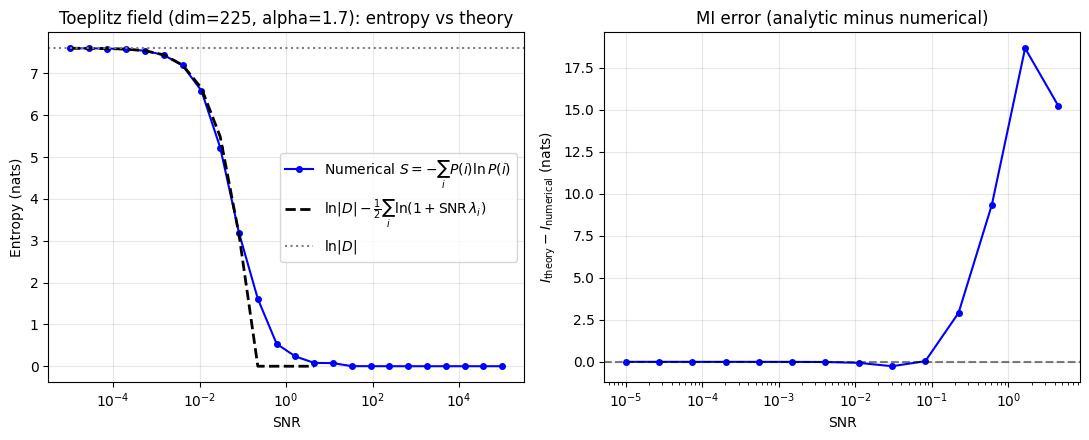

In [4]:
# Sanity check: discrete posterior entropy vs Gaussian MI for Toeplitz field

import math


def discrete_posterior_entropy_nats_field(x_t: torch.Tensor, s_bank: torch.Tensor, alpha_t: float) -> float:
    """Entropy S = -∑ P(i) ln P(i) for discrete posterior over training fields.

    x_t: [N] noisy observation
    s_bank: [D, N] clean training samples
    alpha_t: diffusion-like alpha in [0, 1)
    """
    beta_t = 1.0 - alpha_t
    at_sqrt = math.sqrt(alpha_t)
    # x_t: [N] -> [1, N]
    diff = x_t[None, :] - at_sqrt * s_bank  # [D, N]
    sq_norm = torch.sum(diff * diff, dim=1)  # [D]
    logits = -sq_norm / (2.0 * beta_t)
    logits = logits - logits.max()
    p = torch.exp(logits)
    Z = p.sum()
    if not torch.isfinite(Z) or Z <= 0:
        return float("nan")
    p = (p / Z).detach().cpu().numpy()
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)))


# Small field for MI sanity check (keep covariance manageable)
image_size_sanity = 15
H_s = W_s = image_size_sanity
N_pix_s = H_s * W_s
alpha_field = 1.7
sigma_sq_field = 1.0

# Build Toeplitz-like covariance C(|x - x'|) on a 2D grid
ys_s = torch.arange(H_s, dtype=torch.float32)
xs_s = torch.arange(W_s, dtype=torch.float32)
yy_s, xx_s = torch.meshgrid(ys_s, xs_s, indexing="ij")
coords_s = torch.stack([yy_s.reshape(-1), xx_s.reshape(-1)], dim=1)  # [N, 2]

coords_cpu_s = coords_s.to("cpu")
r_s = torch.cdist(coords_cpu_s, coords_cpu_s, p=2)  # [N, N]

# Avoid singularity at r = 0
eps_s = 1.0
r_safe_s = torch.clamp(r_s, min=eps_s)

if abs(alpha_field - 2.0) < 1e-6:
    C_s = sigma_sq_field * torch.log(r_safe_s)
else:
    power_s = 2.0 - alpha_field
    C_s = sigma_sq_field / (r_safe_s ** power_s)

# Diagonal variance and symmetrize
idx_s = torch.arange(N_pix_s)
C_s[idx_s, idx_s] = sigma_sq_field
C_s = 0.5 * (C_s + C_s.T)
C_s = C_s + 1e-4 * torch.eye(N_pix_s, dtype=C_s.dtype)

# Spectral factor C ≈ Q Λ Q^T
eigvals_s, eigvecs_s = torch.linalg.eigh(C_s)  # [N], [N, N]
eigvals_s_np = eigvals_s.detach().cpu().numpy()

# Clamp eigenvalues to ensure PSD
lam_clamped_s = torch.clamp(eigvals_s, min=1e-6)
L_s = eigvecs_s @ torch.diag(torch.sqrt(lam_clamped_s))  # [N, N]
L_s = L_s.to(device)

# Training bank s_i ~ N(0, C)
D_size_field = 2000
n_trials_field = 50

z_bank = torch.randn((D_size_field, N_pix_s), device=device)
s_bank = z_bank @ L_s.T  # [D, N]

# SNR grid and analytic MI
snr_grid_field = np.logspace(-5, 5, 24)
entropy_numerical_field = np.zeros(len(snr_grid_field))
mi_theory_field = np.zeros(len(snr_grid_field))

for k, snr in enumerate(snr_grid_field):
    alpha_t = snr / (1.0 + snr)
    beta_t = 1.0 / (1.0 + snr)

    S_list = []
    for _ in range(n_trials_field):
        # Clean sample s0 ~ N(0, C)
        g = torch.randn(N_pix_s, device=device)
        s0 = g @ L_s.T  # [N]
        # Noise and observation
        n = torch.randn(N_pix_s, device=device)
        x_t = math.sqrt(alpha_t) * s0 + math.sqrt(beta_t) * n
        S_list.append(discrete_posterior_entropy_nats_field(x_t, s_bank, alpha_t))

    entropy_numerical_field[k] = np.nanmean(S_list)
    # Analytic Gaussian mutual information with eigenvalues λ_i of C
    mi_theory_field[k] = 0.5 * np.sum(np.log(1.0 + snr * eigvals_s_np))

mi_numerical_field = np.log(D_size_field) - entropy_numerical_field

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

S_theory_field = np.maximum(np.zeros_like(mi_theory_field), np.log(D_size_field) - mi_theory_field)

# Left: entropy vs SNR
ax = axes[0]
ax.semilogx(
    snr_grid_field,
    entropy_numerical_field,
    "b-o",
    markersize=4,
    label=r"Numerical $S = -\sum_i P(i)\ln P(i)$",
)
ax.semilogx(
    snr_grid_field,
    S_theory_field,
    "k--",
    linewidth=2,
    label=r"$\ln|D| - \frac{1}{2}\sum_i \ln(1+\mathrm{SNR}\,\lambda_i)$",
)
ax.axhline(np.log(D_size_field), color="gray", linestyle=":", label=r"$\ln|D|$")
ax.set_xlabel("SNR")
ax.set_ylabel("Entropy (nats)")
ax.set_title(f"Toeplitz field (dim={N_pix_s}, alpha={alpha_field}): entropy vs theory")
ax.legend()
ax.grid(True, alpha=0.3)

axes[1].semilogx(snr_grid_field, mi_theory_field - mi_numerical_field, "b-o", markersize=4)
axes[1].axhline(0.0, color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("SNR")
axes[1].set_ylabel(r"$I_{\mathrm{theory}} - I_{\mathrm{numerical}}$ (nats)")
axes[1].set_title("MI error (analytic minus numerical)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


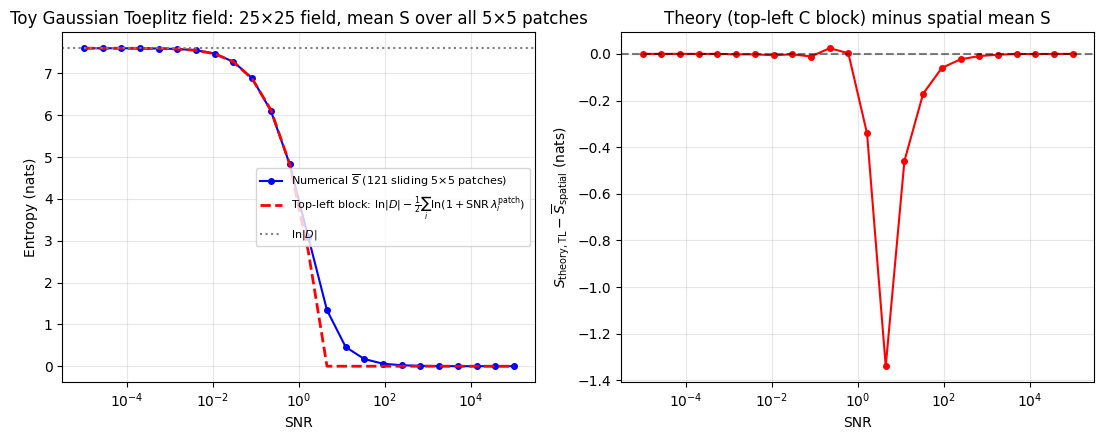

sliding patches = 121 (k=5), patch dim = 25, D_size = 2000, n_trials = 50
Max |S_theory,top-left - S_numerical,spatial-mean|: 1.3393


In [5]:
# 25×25 Toeplitz field: 5×5 patches — mean posterior entropy vs Gaussian theory (top-left block)
# Numerical S: for each trial, average discrete posterior entropy over all valid sliding 5×5 patches
# (same spirit as LS: mean of entropy over spatial locations). Theory line still uses the top-left
# L×L block of C (stationary interior patch; boundary patches have slightly different covariances).

kernel_size_patch = 5
H_p = W_p = kernel_size_patch
H_s = W_s = image_size_sanity

# All valid sliding k×k patches (top-left corners y0,x0 in [0, H-k] × [0, W-k])
idx_patches = []
for y0 in range(H_s - H_p + 1):
    for x0 in range(W_s - W_p + 1):
        idx = []
        for dy in range(H_p):
            for dx in range(W_p):
                idx.append((y0 + dy) * W_s + (x0 + dx))
        idx_patches.append(np.array(idx, dtype=int))
n_patch_pos = len(idx_patches)

# Top-left block: covariance eigenvalues (theory curve)
idx_tl = idx_patches[0]
C_patch = C_s.detach().cpu().numpy()[np.ix_(idx_tl, idx_tl)]
lam_patch, _ = np.linalg.eigh(C_patch)
lam_patch = np.clip(lam_patch, 1e-12, None)

entropy_numerical_patch = np.zeros_like(snr_grid_field)
mi_theory_patch = np.zeros_like(snr_grid_field)

for k, snr in enumerate(snr_grid_field):
    alpha_t = snr / (1.0 + snr)
    beta_t = 1.0 / (1.0 + snr)

    S_list_trial_means = []
    for _ in range(n_trials_field):
        g = torch.randn(N_pix_s, device=device)
        s0 = g @ L_s.T
        n = torch.randn(N_pix_s, device=device)
        x_t = math.sqrt(alpha_t) * s0 + math.sqrt(beta_t) * n

        S_at_pos = []
        for idx_patch in idx_patches:
            x_t_patch = x_t[idx_patch]
            s_bank_patch = s_bank[:, idx_patch]
            S_at_pos.append(
                discrete_posterior_entropy_nats_field(x_t_patch, s_bank_patch, alpha_t)
            )
        S_list_trial_means.append(float(np.nanmean(S_at_pos)))

    entropy_numerical_patch[k] = np.nanmean(S_list_trial_means)
    mi_theory_patch[k] = 0.5 * np.sum(np.log(1.0 + snr * lam_patch))

S_theory_patch = np.maximum(np.zeros_like(mi_theory_patch), np.log(D_size_field) - mi_theory_patch)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: mean over all sliding patches vs top-left-block theory
ax = axes[0]
ax.semilogx(
    snr_grid_field,
    entropy_numerical_patch,
    "b-o",
    markersize=4,
    label=rf"Numerical $\overline{{S}}$ ({n_patch_pos} sliding {kernel_size_patch}×{kernel_size_patch} patches)",
)
ax.semilogx(
    snr_grid_field,
    S_theory_patch,
    "r--",
    linewidth=2,
    label=r"Top-left block: $\ln|D| - \frac{1}{2}\sum_i \ln(1+\mathrm{SNR}\,\lambda_i^{\mathrm{patch}})$",
)
ax.axhline(np.log(D_size_field), color="gray", linestyle=":", label=r"$\ln|D|$")
ax.set_xlabel("SNR")
ax.set_ylabel("Entropy (nats)")
ax.set_title(
    f"Toy Gaussian Toeplitz field: 25×25 field, mean S over all {kernel_size_patch}×{kernel_size_patch} patches"
)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

error_patch = S_theory_patch - entropy_numerical_patch
axes[1].semilogx(snr_grid_field, error_patch, "r-o", markersize=4)
axes[1].axhline(0.0, color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("SNR")
axes[1].set_ylabel(r"$S_{\mathrm{theory,TL}} - \overline{S}_{\mathrm{spatial}}$ (nats)")
axes[1].set_title("Theory (top-left C block) minus spatial mean S")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

max_diff_patch = np.max(np.abs(error_patch))
print(
    f"sliding patches = {n_patch_pos} (k={kernel_size_patch}), patch dim = {H_p*W_p}, "
    f"D_size = {D_size_field}, n_trials = {n_trials_field}"
)
print(f"Max |S_theory,top-left - S_numerical,spatial-mean|: {max_diff_patch:.4f}")


Toy 3D LS grid: done L=3
Toy 3D LS grid: done L=5
Toy 3D LS grid: done L=7
Toy 3D LS grid: done L=9
Toy 3D LS grid: done L=11
Toy 3D LS grid: done L=13
Toy 3D LS grid: done L=15
Saved /home/users/hshunt/convolutional_diffusion/results/toy_gaussian_toeplitz_mi_grid_15x15.npz


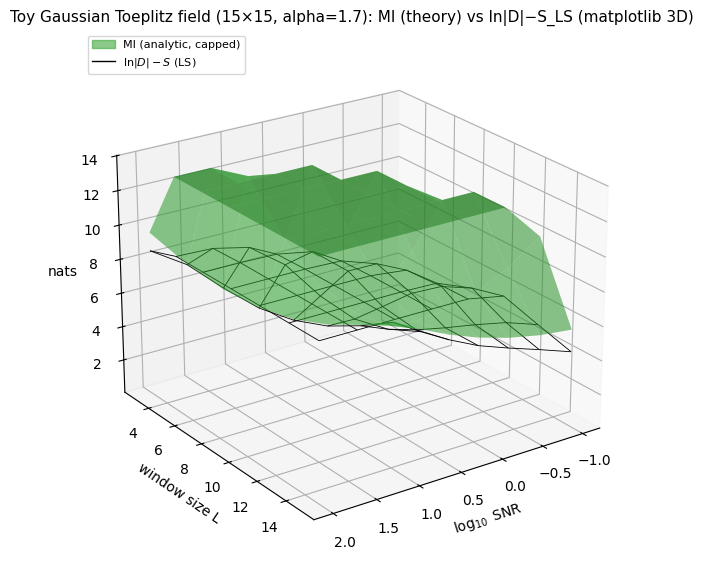

Saved /home/users/hshunt/convolutional_diffusion/results/toy_gaussian_toeplitz_mi_3d_15x15.png


In [15]:
# 3D surface: log10(SNR), kernel size L, z = analytic patch MI (green) and entropy deficit ln|D|−S (LS wireframe)
# Requires: cell 1 (ROOT, plt), cell 2 (imports, device, cosine_noise_schedule), cell 4 (H_s, W_s, C_s, L_s, alpha_field, sigma_sq_field).

import numpy as np
import torch
from torch.utils.data import TensorDataset

from src.utils.idealscore import LocalScoreModule


def _snr_to_t_cosine(snr: float, dev: torch.device) -> float:
    target = 1.0 / (1.0 + float(snr))
    lo, hi = 1e-5, 1.0 - 1e-5
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        b = float(cosine_noise_schedule(torch.tensor([mid], device=dev)).item())
        if b < target:
            lo = mid
        else:
            hi = mid
    return float(0.5 * (lo + hi))


def _analytic_mi_top_left(snr: float, L: int, C_np: np.ndarray, Wg: int) -> float:
    idx = np.array([yi * Wg + xi for yi in range(L) for xi in range(L)], dtype=int)
    Cp = C_np[np.ix_(idx, idx)]
    lam = np.linalg.eigvalsh(Cp)
    lam = np.clip(lam, 1e-18, None)
    return float(0.5 * np.sum(np.log(1.0 + snr * lam)))


C_np_toy = C_s.detach().cpu().numpy()
n_D_toy = 10000#min(2048, 50000)
train_n_toy = max(n_D_toy, 4096)
rng_t3d = np.random.default_rng(0)
z_tr = rng_t3d.standard_normal((train_n_toy, N_pix_s))
L_np_toy = L_s.detach().cpu().numpy()
flat_tr = z_tr @ L_np_toy.T
train_imgs = flat_tr.reshape(train_n_toy, 1, H_s, W_s).astype(np.float32)
train_ds_toy3d = TensorDataset(
    torch.from_numpy(train_imgs).float(),
    torch.zeros(train_n_toy, dtype=torch.long),
)

ls_L_toy = np.array([L for L in [3, 5, 7, 9, 11, 13, 15] if L <= H_s], dtype=int)
ls_snr_toy = np.logspace(-1.0, 2.0, 8)
L_mesh_t, snr_mesh_t = np.meshgrid(ls_L_toy.astype(float), ls_snr_toy, indexing="ij")

Z_mi_toy = np.zeros_like(L_mesh_t, dtype=np.float64)
for i in range(L_mesh_t.shape[0]):
    Lk = int(L_mesh_t[i, 0])
    for j in range(L_mesh_t.shape[1]):
        Z_mi_toy[i, j] = _analytic_mi_top_left(float(snr_mesh_t[i, j]), Lk, C_np_toy, W_s)

n_ev_t = min(32, len(train_ds_toy3d))
rng_ev_t = np.random.default_rng(1)
ev_idx_t = rng_ev_t.choice(len(train_ds_toy3d), size=n_ev_t, replace=False)
eval_x0_t = torch.stack([train_ds_toy3d[int(k)][0] for k in ev_idx_t]).to(device)

eps_cols_t = []
for j in range(ls_snr_toy.shape[0]):
    torch.manual_seed(42 + j)
    eps_cols_t.append(torch.randn_like(eval_x0_t, device=device))

Z_S_toy = np.zeros_like(Z_mi_toy, dtype=np.float64)
ls_batch_toy = min(32, n_D_toy)
for i, Lk in enumerate(ls_L_toy):
    ls_mod_t = (
        LocalScoreModule(
            train_ds_toy3d,
            kernel_size=int(Lk),
            image_size=H_s,
            batch_size=ls_batch_toy,
            schedule=cosine_noise_schedule,
            max_samples=n_D_toy,
        )
        .to(device)
        .eval()
    )
    for j, snr in enumerate(ls_snr_toy):
        t_val = _snr_to_t_cosine(float(snr), device)
        t = torch.tensor([t_val], device=device, dtype=torch.float32)
        beta_t = cosine_noise_schedule(t)
        at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
        bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))
        xt = at * eval_x0_t + bt * eps_cols_t[j]
        with torch.no_grad():
            out = ls_mod_t.forward_with_posterior_stats(t, xt, device=device)
            Z_S_toy[i, j] = float(out[2].mean().item())
        if device.type == "cuda":
            torch.cuda.empty_cache()
    del ls_mod_t
    if device.type == "cuda":
        torch.cuda.empty_cache()
    print(f"Toy 3D LS grid: done L={Lk}")

log_D_toy = float(np.log(float(n_D_toy)))
Z_def_toy = log_D_toy - Z_S_toy

toy_gauss_3d_pack = {
    "L_mesh": L_mesh_t,
    "snr_mesh": snr_mesh_t,
    "Z_mi": Z_mi_toy,
    "Z_S_ls": Z_S_toy,
    "Z_deficit_ls": Z_def_toy,
    "log_D": log_D_toy,
    "n_D": n_D_toy,
    "H": H_s,
    "alpha_field": alpha_field,
}

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

log_snr_t = np.log10(snr_mesh_t)
z_cap_t = 1.5 * toy_gauss_3d_pack["log_D"]
z_top_t = float(0.995 * z_cap_t)
Z_mi_plot_t = np.minimum(Z_mi_toy.astype(float), z_top_t)

fig_t3d = plt.figure(figsize=(10, 7))
ax_t3d = fig_t3d.add_subplot(111, projection="3d")
ax_t3d.plot_surface(
    log_snr_t,
    L_mesh_t,
    Z_mi_plot_t,
    color="#2ca02c",
    alpha=0.55,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=True,
)
ax_t3d.plot_wireframe(
    log_snr_t,
    L_mesh_t,
    Z_def_toy,
    color="black",
    linewidth=0.6,
    rstride=1,
    cstride=1,
)

ax_t3d.set_xlabel(r"$\log_{10}$ SNR")
ax_t3d.set_ylabel("window size L")
ax_t3d.set_zlabel("nats")
ax_t3d.set_title(
    f"Toy Gaussian Toeplitz field ({H_s}×{W_s}, alpha={alpha_field}): "
    "MI (theory) vs ln|D|−S_LS (matplotlib 3D)",
    fontsize=11,
)
ax_t3d.view_init(elev=23, azim=55)
ax_t3d.legend(
    handles=[
        Patch(facecolor="#2ca02c", edgecolor="#2ca02c", alpha=0.55, label="MI (analytic, capped)"),
        Line2D([0], [0], color="black", lw=1.0, label=r"$\ln|D|-S$ (LS)"),
    ],
    loc="upper left",
    fontsize=8,
)

save_dir_t = ROOT / "results"
save_dir_t.mkdir(parents=True, exist_ok=True)

npz_path_t = save_dir_t / f"toy_gaussian_toeplitz_mi_grid_{H_s}x{W_s}.npz"
np.savez_compressed(
    npz_path_t,
    L_mesh=L_mesh_t,
    snr_mesh=snr_mesh_t,
    log10_snr=np.log10(snr_mesh_t),
    Z_mi=Z_mi_toy,
    Z_S_ls=Z_S_toy,
    Z_deficit_ls=Z_def_toy,
    log_D=log_D_toy,
    n_D=np.array(n_D_toy, dtype=np.int64),
    ls_L_coarse=ls_L_toy.astype(np.float64),
    ls_snr_coarse=ls_snr_toy.astype(np.float64),
    H=np.array(H_s, dtype=np.int64),
    W=np.array(W_s, dtype=np.int64),
    alpha_field=np.array(alpha_field, dtype=np.float64),
)
print("Saved", npz_path_t)

png_path_t = save_dir_t / f"toy_gaussian_toeplitz_mi_3d_{H_s}x{W_s}.png"
fig_t3d.savefig(png_path_t, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", png_path_t)


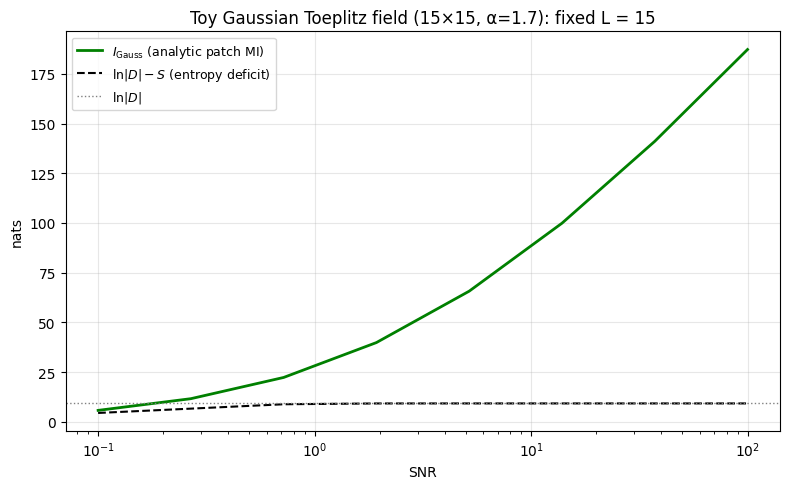

Saved /home/users/hshunt/convolutional_diffusion/results/toy_gaussian_toeplitz_fixedL15_15x15.png


In [14]:
# 2D curves at fixed kernel size L: MI (theory), LS entropy S, and deficit ln|D|−S vs SNR
# Requires: `toy_gauss_3d_pack` from the previous cell (3D grid compute).

if "toy_gauss_3d_pack" not in globals():
    raise RuntimeError("Run the cell above that defines `toy_gauss_3d_pack` first.")

L_fixed = 15  # edit: must appear in ls_L_toy used for the grid

_pack = toy_gauss_3d_pack
ls_L = np.asarray([int(_pack["L_mesh"][i, 0]) for i in range(_pack["L_mesh"].shape[0])])
if L_fixed not in ls_L:
    raise ValueError(f"L_fixed={L_fixed} not in grid {ls_L.tolist()}; change L_fixed or re-run compute cell.")

i_row = int(np.where(ls_L == L_fixed)[0][0])
snr_1d = _pack["snr_mesh"][i_row, :].astype(float)
Z_mi_1d = _pack["Z_mi"][i_row, :].astype(float)
Z_S_1d = _pack["Z_S_ls"][i_row, :].astype(float)
Z_def_1d = _pack["Z_deficit_ls"][i_row, :].astype(float)
log_D = float(_pack["log_D"])

fig_L, ax_L = plt.subplots(1, 1, figsize=(8, 5))
ax_L.semilogx(snr_1d, Z_mi_1d, "g-", linewidth=2, label=r"$I_{\mathrm{Gauss}}$ (analytic patch MI)")
# ax_L.semilogx(snr_1d, Z_S_1d, "b-o", markersize=4, label=r"$S$ (LS posterior entropy)")
ax_L.semilogx(snr_1d, Z_def_1d, "k--", linewidth=1.5, label=r"$\ln|D|-S$ (entropy deficit)")
ax_L.axhline(log_D, color="gray", linestyle=":", linewidth=1, label=r"$\ln|D|$")
ax_L.set_xlabel("SNR")
ax_L.set_ylabel("nats")
ax_L.set_title(
    f"Toy Gaussian Toeplitz field ({_pack['H']}×{_pack['H']}, α={_pack['alpha_field']}): "
    f"fixed L = {L_fixed}"
)
ax_L.legend(loc="best", fontsize=9)
ax_L.grid(True, alpha=0.3)
plt.tight_layout()

_out_L = ROOT / "results" / f"toy_gaussian_toeplitz_fixedL{L_fixed}_{_pack['H']}x{_pack['H']}.png"
_out_L.parent.mkdir(parents=True, exist_ok=True)
fig_L.savefig(_out_L, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", _out_L)


<>:44: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_25459/3163007346.py:44: SyntaxWarning: invalid escape sequence '\o'
  f"Toy Gaussian Toeplitz field: 25×25, {kernel_size_patch}×{kernel_size_patch} — empirical-λ theory vs $\overline{{S}}$"
Saved /home/users/hshunt/results/toeplitz_field15x15_patch5x5_entropy_vs_theory.svg


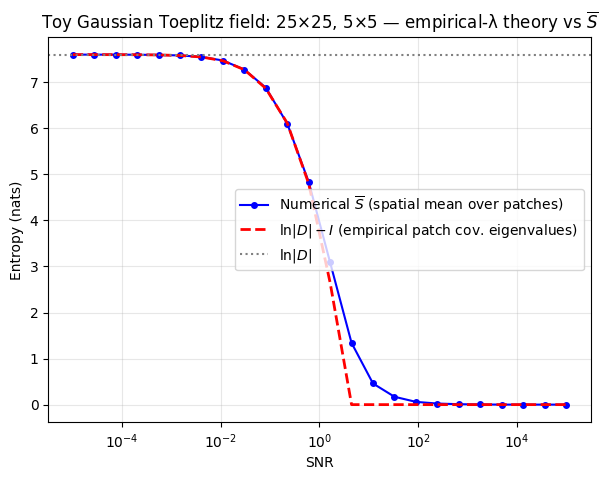

In [9]:
def gaussian_mutual_information(snr_value, covariance_singular_values):
    """Discrete MI in nats: (1/2) sum_k log(1 + SNR*A*|k|^{-alpha})."""
    
    return 0.5*np.sum(np.log(1.0 + snr_value*covariance_singular_values))

# Log-log plot: eigenvalue index vs eigenvalue (top-left patch of training bank; same block as theory λ)
patches = s_bank[:, idx_tl]
patches_centered = patches - patches.mean(axis=0)
cov_patch = (patches_centered.T @ patches_centered) / max(patches_centered.shape[0] - 1, 1)
evals_patch, _ = np.linalg.eigh(cov_patch.cpu().numpy())

beta_values = snr_grid_field

gaussian_mi = [
    gaussian_mutual_information(b, evals_patch)
    for b in beta_values
]
gaussian_mi = np.array(gaussian_mi)


S_theory_patch = np.maximum(np.zeros_like(gaussian_mi), np.log(D_size_field) - gaussian_mi)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Empirical-λ MI vs spatial-mean numerical S (from previous cell)
ax.semilogx(
    snr_grid_field,
    entropy_numerical_patch,
    "b-o",
    markersize=4,
    label=r"Numerical $\overline{S}$ (spatial mean over patches)",
)
ax.semilogx(
    snr_grid_field,
    S_theory_patch,
    "r--",
    linewidth=2,
    label=r"$\ln|D| - I$ (empirical patch cov. eigenvalues)",
)
ax.axhline(np.log(D_size_field), color="gray", linestyle=":", label=r"$\ln|D|$")
ax.set_xlabel("SNR")
ax.set_ylabel("Entropy (nats)")
ax.set_title(
    f"Toy Gaussian Toeplitz field: 25×25, {kernel_size_patch}×{kernel_size_patch} — empirical-λ theory vs $\overline{{S}}$"
)
ax.legend()
ax.grid(True, alpha=0.3)

# Save Toeplitz patch entropy vs theory plot (previous cell) as SVG

save_dir = ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)

fig = plt.gcf()
out_path = save_dir / f"toeplitz_field{image_size_sanity}x{image_size_sanity}_patch{kernel_size_patch}x{kernel_size_patch}_entropy_vs_theory.svg"
fig.savefig(out_path, format="svg")
print(f"Saved {out_path}")

In [10]:
def build_candidate_bank(score_machine_name, dataset, image_size, channels=3, score_batch_size=64, max_samples=5000, 
                         kernel_size = 17):
    """Build score machine modules (LS/ELS/bbELS) using forward_with_posterior_stats where available."""
    common_kwargs = dict(
        kernel_size=kernel_size,
        batch_size=score_batch_size,
        image_size=image_size,
        channels=channels,
        schedule=cosine_noise_schedule,
        max_samples=max_samples,
        shuffle=False,
    )

    score_machine_name = score_machine_name.lower()
    if score_machine_name == "ls":
        mod = LocalScoreModule(
            dataset,
            kernel_size=kernel_size,
            image_size=image_size,
            batch_size=score_batch_size,
            schedule=cosine_noise_schedule,
            max_samples=max_samples,
        )
    elif score_machine_name == "els":
        mod = LocalEquivScoreModule(dataset, **common_kwargs)
    elif score_machine_name == "bbels":
        mod = LocalEquivBordersScoreModule(dataset, **common_kwargs)
    else:
        raise ValueError(f"Unknown score machine: {score_machine_name}")

    mod.to(device).eval()
    return mod


def posterior_entropy_nats_from_score_machine(score_machine, t, xt):
    """Use forward_with_posterior_stats to estimate entropy in nats.

    For IdealScoreModule (global ideal posterior), fall back to an explicit
    discrete posterior over the training set using the same energy as in
    src.utils.idealscore.IdealScoreModule.
    """
    # IdealScoreModule special case: exact discrete posterior over full images
    if isinstance(score_machine, IdealScoreModule):
        # xt: [B, C, H, W]; we use all eval batch images independently but share training set
        with torch.no_grad():
            B = xt.shape[0]
            # Stack all training images into one tensor on device
            train_imgs = train_x0.to(device)  # [N, C, H, W]
            N = train_imgs.shape[0]
            # Broadcast differences: [B, N, C, H, W]
            beta_t = cosine_noise_schedule(t).to(device)
            bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))
            at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12)).to(device)
            x_exp = xt[:, None, :, :, :]  # [B, 1, C, H, W]
            imgs_exp = train_imgs[None, :, :, :, :]  # [1, N, C, H, W]
            pwise_diffs = x_exp - at * imgs_exp
            exp_args = -torch.sum(pwise_diffs ** 2, dim=(2, 3, 4)) / (2.0 * bt**2)  # [B, N]
            # For each B, entropy = log Z - (1/Z) * sum_i w_i * log w_i, w_i = exp(exp_args_i)
            # Work in numpy for convenience
            exp_args_np = exp_args.detach().cpu().numpy()
            entropies = []
            for row in exp_args_np:
                m = np.max(row)
                w = np.exp(row - m)
                Z = np.sum(w)
                if not np.isfinite(Z) or Z <= 0:
                    entropies.append(0.0)
                    continue
                logw = row  # since w_i ∝ exp(row_i)
                H = np.log(Z) + m - (w @ logw) / Z
                # Clamp to [0, ln N]
                H = float(np.clip(H, 0.0, np.log(max(N, 1))))
                entropies.append(H)
            return float(np.mean(entropies))

    if hasattr(score_machine, "forward_with_posterior_stats"):
        out = score_machine.forward_with_posterior_stats(t, xt, device=device, k=3)
        entropy_nats = out[2].mean().item()
        return float(entropy_nats)

    # Fallback for bbELS: use local module posterior stats proxy.
    if hasattr(score_machine, "local_module") and hasattr(score_machine.local_module, "forward_with_posterior_stats"):
        out = score_machine.local_module.forward_with_posterior_stats(t, xt, device=device, k=3)
        entropy_nats = out[2].mean().item()
        return float(entropy_nats)

    return float("nan")


# train_posterior_samples = min(cfg.posterior_max_samples, len(train_dataset))
# kernel_size = 17
# ls_machine = build_candidate_bank(
#     "ls",
#     train_dataset,
#     image_size=cfg.image_size,
#     channels=eval_x0.shape[1],
#     score_batch_size=cfg.score_batch_size,
#     max_samples=train_posterior_samples,
#     kernel_size=kernel_size
# )
# els_machine = build_candidate_bank(
#     "els",
#     train_dataset,
#     image_size=cfg.image_size,
#     channels=eval_x0.shape[1],
#     score_batch_size=cfg.score_batch_size,
#     max_samples=train_posterior_samples,
#     kernel_size=kernel_size
# )
# bbels_machine = build_candidate_bank(
#     "bbels",
#     train_dataset,
#     image_size=cfg.image_size,
#     channels=eval_x0.shape[1],
#     score_batch_size=cfg.score_batch_size,
#     max_samples=train_posterior_samples,
#     kernel_size=kernel_size
# )
# # Global ideal score machine (no locality / patches)
# ideal_machine = IdealScoreModule(
#     train_dataset,
#     image_size=cfg.image_size,
#     batch_size=cfg.score_batch_size,
#     schedule=cosine_noise_schedule,
#     max_samples=train_posterior_samples,
#     shuffle=False,
# ).to(device).eval()

# print(f"score machines ready (k={kernel_size}).")
# print("train_posterior_samples:", train_posterior_samples)
# print("score_batch_size:", cfg.score_batch_size)

Computing 5x5 LS entropy deficits for CelebA...
Files already downloaded and verified
Files already downloaded and verified


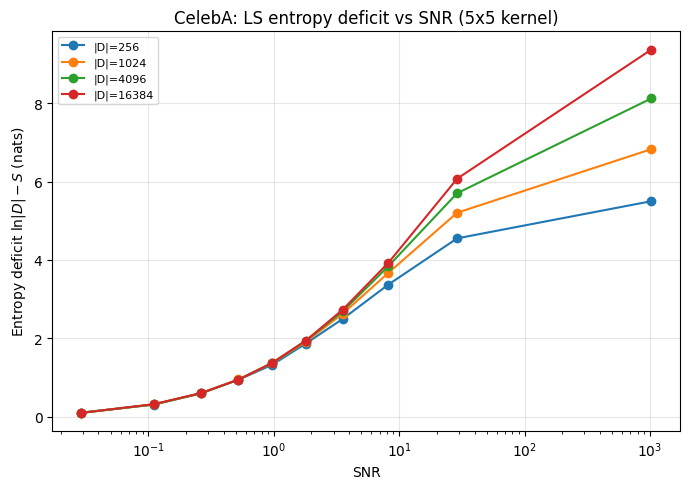

Computing 5x5 LS entropy deficits for CIFAR-10...
Files already downloaded and verified
Files already downloaded and verified


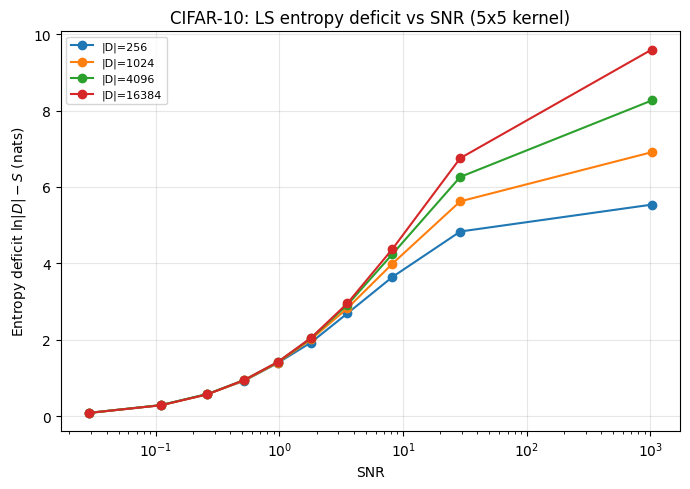

Computing 5x5 LS entropy deficits for MNIST...


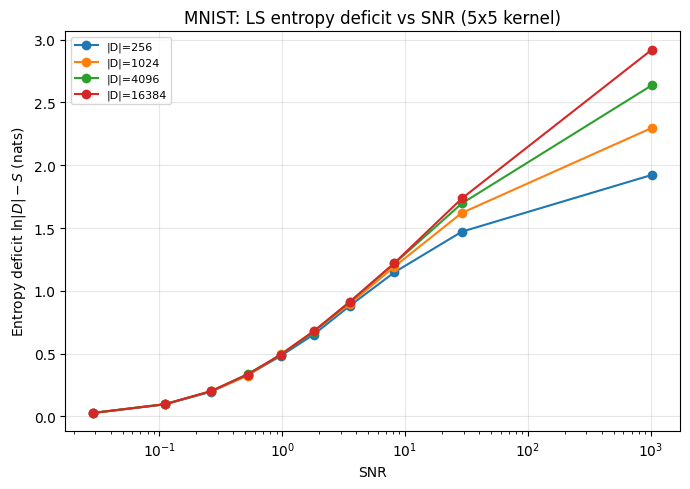

Done computing 5x5 LS entropy deficits for CelebA, CIFAR-10, and MNIST.


In [17]:
# LS 5x5 entropy deficit vs SNR for CelebA, CIFAR10, and MNIST

from torch.utils.data import DataLoader

# Store results per dataset for use in the next cell (patch covariance + Gaussian MI plot).
ls_5x5_results = {}

# Use the same time grid as the main LS experiment if available
if "cfg" in globals() and hasattr(cfg, "t_values"):
    t_grid_ls = list(cfg.t_values)
else:
    # Fallback: a reasonable log-spaced grid in (0, 1)
    t_grid_ls = np.linspace(0.02, 0.9, 10).tolist()

# Helper to turn t -> SNR using the cosine schedule
with torch.no_grad():
    t_tensor = torch.tensor(t_grid_ls, device=device, dtype=torch.float32)
    beta_t_grid = cosine_noise_schedule(t_tensor)
    snr_grid_ls = ((1.0 - beta_t_grid) / (beta_t_grid + 1e-12)).cpu().numpy()

kernel_size_ls = 5
score_batch_size_ls = getattr(cfg, "score_batch_size", 64) if "cfg" in globals() else 64

datasets_to_plot = [
    ("celeba", "CelebA"),
    ("cifar10", "CIFAR-10"),
    ("mnist", "MNIST"),
]

for ds_name, ds_title in datasets_to_plot:
    print(f"Computing {kernel_size_ls}x{kernel_size_ls} LS entropy deficits for {ds_title}...")

    # Load training and validation/test splits
    train_dataset, meta = get_dataset(ds_name, train=True)
    eval_dataset, _ = get_dataset(ds_name, train=False)

    image_size = int(meta["image_size"])
    channels = int(meta["num_channels"])

    # Evaluation batch (noisy observations are built from this set)
    eval_batch_size = min(64, len(eval_dataset))
    eval_loader = DataLoader(eval_dataset, batch_size=eval_batch_size, shuffle=False)
    eval_x0, _ = next(iter(eval_loader))
    eval_x0 = eval_x0.to(device)

    # Training set sizes: 2^8, 2^10, 2^12, 2^14 (capped by dataset size)
    n_train_powers = [8, 10, 12, 14]
    max_available = len(train_dataset)
    n_train_list = [min(2**k, max_available) for k in n_train_powers]
    n_train_list = sorted(set(n_train_list))

    entropy_deficit_by_n_5x5 = {}

    for n_train in n_train_list:
        with torch.no_grad():
            # LS module with 5x5 kernel and n_train samples
            ls_n = LocalScoreModule(
                train_dataset,
                kernel_size=kernel_size_ls,
                image_size=image_size,
                batch_size=score_batch_size_ls,
                schedule=cosine_noise_schedule,
                max_samples=n_train,
            ).to(device).eval()

            deficits = []
            for t_val in t_grid_ls:
                t = torch.tensor([t_val], device=device, dtype=torch.float32)
                beta_t = cosine_noise_schedule(t)
                at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
                bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))

                # Noisy test observation built from eval_x0
                eps = torch.randn_like(eval_x0, device=device)
                xt = at * eval_x0 + bt * eps

                s_nats = posterior_entropy_nats_from_score_machine(ls_n, t, xt)
                log_D = np.log(n_train)
                deficits.append(float(log_D - s_nats))

                if "cfg" in globals() and getattr(cfg, "empty_cache_each_call", False) and device.type == "cuda":
                    torch.cuda.empty_cache()

            entropy_deficit_by_n_5x5[n_train] = np.array(deficits)

        del ls_n
        if device.type == "cuda":
            torch.cuda.empty_cache()

    # Save for next cell (patch covariance + Gaussian MI plot)
    ls_5x5_results[ds_name] = {
        "snr": np.array(snr_grid_ls),
        "deficit_by_n": {n: np.array(arr) for n, arr in entropy_deficit_by_n_5x5.items()},
        "n_train_list": list(n_train_list),
        "kernel_size": kernel_size_ls,
        "title": ds_title,
    }

    # Plot entropy deficits for this dataset
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    for n_train in n_train_list:
        ax.plot(snr_grid_ls, entropy_deficit_by_n_5x5[n_train], "o-", label=f"|D|={n_train}")

    ax.set_xscale("log")
    ax.set_xlabel("SNR")
    ax.set_ylabel(r"Entropy deficit $\ln|D| - S$ (nats)")
    ax.set_title(f"{ds_title}: LS entropy deficit vs SNR ({kernel_size_ls}x{kernel_size_ls} kernel)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

print("Done computing 5x5 LS entropy deficits for CelebA, CIFAR-10, and MNIST.")


In [ ]:
# Save 5x5 LS entropy deficit plots (cell 7) as SVGs

save_dir = ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)

for ds_name, info in ls_5x5_results.items():
    snr = info["snr"]
    deficit_by_n = info["deficit_by_n"]
    n_train_list = info["n_train_list"]
    k = info["kernel_size"]
    ds_title = info["title"]

    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    for n_train in n_train_list:
        ax.plot(snr, deficit_by_n[n_train], "o-", label=f"|D|={n_train}")
    ax.set_xscale("log")
    ax.set_xlabel("SNR")
    ax.set_ylabel(r"Entropy deficit $\ln|D| - S$ (nats)")
    ax.set_title(f"{ds_title}: LS entropy deficit vs SNR ({k}x{k} kernel)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()

    out_path = save_dir / f"ls_5x5_entropy_deficit_{ds_name}.svg"
    fig.savefig(out_path, format="svg")
    plt.close(fig)
    print(f"Saved {out_path}")

In [20]:
# Patch covariance (data processing) — uses ls_5x5_results from previous cell

from torch.utils.data import DataLoader

max_samples_patch_cov = 2**14
patch_cov_results = {}

for ds_name, info in ls_5x5_results.items():
    k = info["kernel_size"]
    train_dataset, meta = get_dataset(ds_name, train=True)
    n_use = min(max_samples_patch_cov, len(train_dataset))
    loader = DataLoader(train_dataset, batch_size=min(256, n_use), shuffle=False)
    patches_list = []
    count = 0
    for batch, _ in loader:
        patch = batch[:, :, :k, :k].reshape(batch.shape[0], -1)
        patches_list.append(patch.cpu().numpy())
        count += batch.shape[0]
        if count >= n_use:
            break
    patches = np.concatenate(patches_list, axis=0)[:n_use]

    patches_centered = patches - patches.mean(axis=0)
    cov_patch = (patches_centered.T @ patches_centered) / max(patches_centered.shape[0] - 1, 1)
    evals_patch, _ = np.linalg.eigh(cov_patch)
    evals_patch = np.clip(evals_patch, 1e-12, None)

    patch_cov_results[ds_name] = {"evals_patch": evals_patch, "k": k, "title": info["title"]}


Files already downloaded and verified
Files already downloaded and verified


In [21]:
# Gaussian MI in nats: (1/2) sum_i log(1 + SNR * lambda_i) per dataset

gaussian_mi_results = {}
for ds_name in patch_cov_results:
    snr = ls_5x5_results[ds_name]["snr"]
    evals_patch = patch_cov_results[ds_name]["evals_patch"]
    gaussian_mi_results[ds_name] = np.array(
        [0.5 * np.sum(np.log(1.0 + snr_val * evals_patch)) for snr_val in snr]
    )

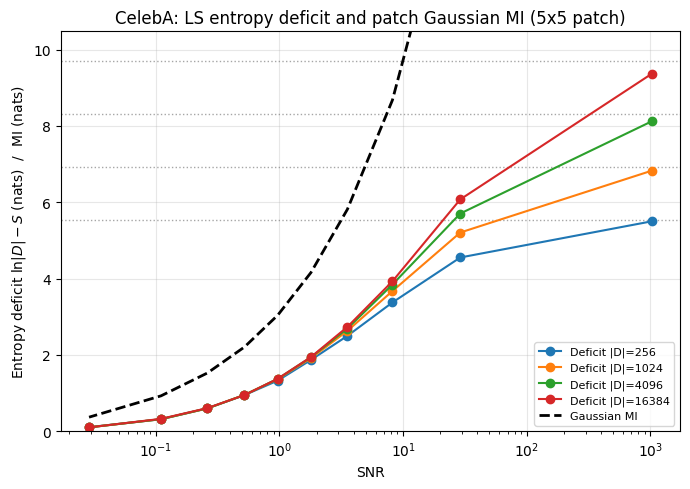

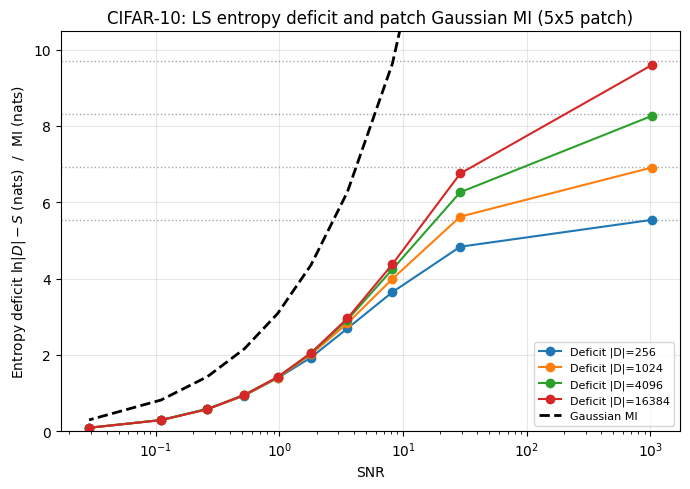

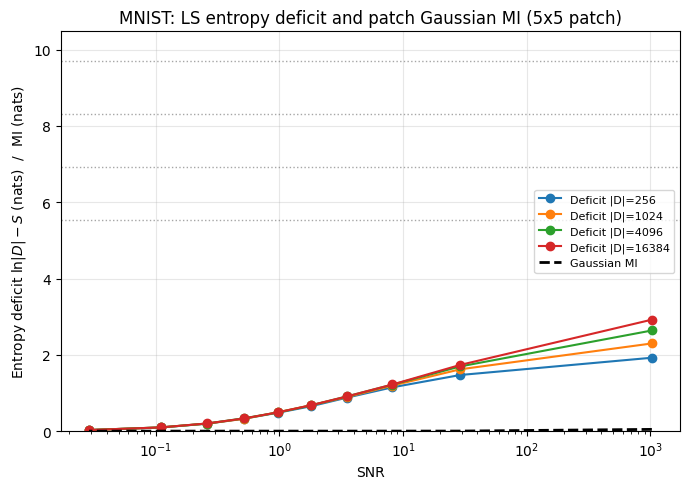

In [22]:
# Plot entropy deficit curves + horizontal ln|D| lines + Gaussian MI

for ds_name in ls_5x5_results:
    info = ls_5x5_results[ds_name]
    snr = info["snr"]
    deficit_by_n = info["deficit_by_n"]
    n_train_list = info["n_train_list"]
    k = info["kernel_size"]
    ds_title = info["title"]
    gaussian_mi = gaussian_mi_results[ds_name]

    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    max_log_D = max(np.log(n) for n in n_train_list)
    for n_train in n_train_list:
        ax.axhline(np.log(n_train), color="gray", linestyle=":", alpha=0.7, linewidth=1)
    for n_train in n_train_list:
        ax.plot(snr, deficit_by_n[n_train], "o-", label=f"Deficit |D|={n_train}")
    ax.plot(snr, gaussian_mi, "k--", linewidth=2, label="Gaussian MI")
    ax.set_xscale("log")
    ax.set_ylim(0, max_log_D * 1.08)
    ax.set_xlabel("SNR")
    ax.set_ylabel(r"Entropy deficit $\ln|D| - S$ (nats)  /  MI (nats)")
    ax.set_title(f"{ds_title}: LS entropy deficit and patch Gaussian MI ({k}x{k} patch)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

In [23]:
# Export each plot as SVG

save_dir = ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)

for ds_name in ls_5x5_results:
    info = ls_5x5_results[ds_name]
    snr = info["snr"]
    deficit_by_n = info["deficit_by_n"]
    n_train_list = info["n_train_list"]
    k = info["kernel_size"]
    ds_title = info["title"]
    gaussian_mi = gaussian_mi_results[ds_name]

    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    max_log_D = max(np.log(n) for n in n_train_list)
    for n_train in n_train_list:
        ax.axhline(np.log(n_train), color="gray", linestyle=":", alpha=0.7, linewidth=1)
    for n_train in n_train_list:
        ax.plot(snr, deficit_by_n[n_train], "o-", label=f"Deficit |D|={n_train}")
    ax.plot(snr, gaussian_mi, "k--", linewidth=2, label="Gaussian MI")
    ax.set_xscale("log")
    ax.set_ylim(0, max_log_D * 1.08)
    ax.set_xlabel("SNR")
    ax.set_ylabel(r"Entropy deficit $\ln|D| - S$ (nats)  /  MI (nats)")
    ax.set_title(f"{ds_title}: LS entropy deficit and patch Gaussian MI ({k}x{k} patch)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    out_path = save_dir / f"entropy_deficit_gaussian_mi_{ds_name}.svg"
    fig.savefig(out_path, format="svg")
    plt.close(fig)
    print(f"Saved {out_path}")

Saved /home/users/hshunt/convolutional_diffusion/results/entropy_deficit_gaussian_mi_celeba.svg
Saved /home/users/hshunt/convolutional_diffusion/results/entropy_deficit_gaussian_mi_cifar10.svg
Saved /home/users/hshunt/convolutional_diffusion/results/entropy_deficit_gaussian_mi_mnist.svg


In [ ]:
def posterior_entropy_nats_from_score_machine(score_machine, t, xt):
    """Use forward_with_posterior_stats to estimate entropy in nats.

    For IdealScoreModule (global ideal posterior), fall back to an explicit
    discrete posterior over the training set using the same energy as in
    src.utils.idealscore.IdealScoreModule.
    """
    # IdealScoreModule special case: exact discrete posterior over full images
    if isinstance(score_machine, IdealScoreModule):
        # xt: [B, C, H, W]; we use all eval batch images independently but share training set
        with torch.no_grad():
            B = xt.shape[0]
            train_imgs = train_x0.to(device)  # [N, C, H, W]
            N = train_imgs.shape[0]
            beta_t = cosine_noise_schedule(t).to(device)
            bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))
            at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12)).to(device)
            x_exp = xt[:, None, :, :, :]  # [B, 1, C, H, W]
            imgs_exp = train_imgs[None, :, :, :, :]  # [1, N, C, H, W]
            pwise_diffs = x_exp - at * imgs_exp
            exp_args = -torch.sum(pwise_diffs ** 2, dim=(2, 3, 4)) / (2.0 * bt**2)  # [B, N]
            exp_args_np = exp_args.detach().cpu().numpy()
            entropies = []
            for row in exp_args_np:
                m = np.max(row)
                w = np.exp(row - m)
                Z = np.sum(w)
                if not np.isfinite(Z) or Z <= 0:
                    entropies.append(0.0)
                    continue
                logw = row
                H = np.log(Z) + m - (w @ logw) / Z
                H = float(np.clip(H, 0.0, np.log(max(N, 1))))
                entropies.append(H)
            return float(np.mean(entropies))

    if hasattr(score_machine, "forward_with_posterior_stats"):
        out = score_machine.forward_with_posterior_stats(t, xt, device=device, k=3)
        entropy_nats = out[2].mean().item()
        return float(entropy_nats)

    # Fallback for bbELS: use local module posterior stats proxy.
    if hasattr(score_machine, "local_module") and hasattr(score_machine.local_module, "forward_with_posterior_stats"):
        out = score_machine.local_module.forward_with_posterior_stats(t, xt, device=device, k=3)
        entropy_nats = out[2].mean().item()
        return float(entropy_nats)

    return float("nan")


# Alias for code that calls this name (e.g. 5x5 LS deficit cell).
discrete_posterior_entropy_nats_from_score_machine = posterior_entropy_nats_from_score_machine


In [35]:
# Test entropies: noisy observations xt are from eval_x0 (test/validation set), not training.
results = {"t": [], "snr": [], "LS": [], "ELS": [], "bbELS": [], "Ideal": []}

for t_val in cfg.t_values:
    t = torch.tensor([t_val], device=device, dtype=torch.float32)
    beta_t = cosine_noise_schedule(t)
    at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
    bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))

    with torch.no_grad():
        # Noisy test observation (eval_x0 = test set)
        eps = torch.randn_like(eval_x0, device=device)
        xt = at * eval_x0 + bt * eps

        h_ls = posterior_entropy_nats_from_score_machine(ls_machine, t, xt)
        if cfg.empty_cache_each_call and device.type == "cuda":
            torch.cuda.empty_cache()

        h_els = posterior_entropy_nats_from_score_machine(els_machine, t, xt)
        if cfg.empty_cache_each_call and device.type == "cuda":
            torch.cuda.empty_cache()

        h_bbels = posterior_entropy_nats_from_score_machine(bbels_machine, t, xt)
        if cfg.empty_cache_each_call and device.type == "cuda":
            torch.cuda.empty_cache()

        # Ideal global score entropy (IdealScoreModule)
        h_ideal = posterior_entropy_nats_from_score_machine(ideal_machine, t, xt)
        if cfg.empty_cache_each_call and device.type == "cuda":
            torch.cuda.empty_cache()

    snr = ((1.0 - beta_t) / (beta_t + 1e-12)).item()
    results["t"].append(float(t_val))
    results["snr"].append(float(snr))
    results["LS"].append(h_ls)
    results["ELS"].append(h_els)
    results["bbELS"].append(h_bbels)
    results["Ideal"].append(h_ideal)

print("Finished. Example row:")
print({k: v[0] for k, v in results.items()})


Finished. Example row:
{'t': 0.05, 'snr': 164.05210876464844, 'LS': 0.2577434182167053, 'ELS': 2.1459712982177734, 'bbELS': 0.2577434778213501, 'Ideal': 0.0}


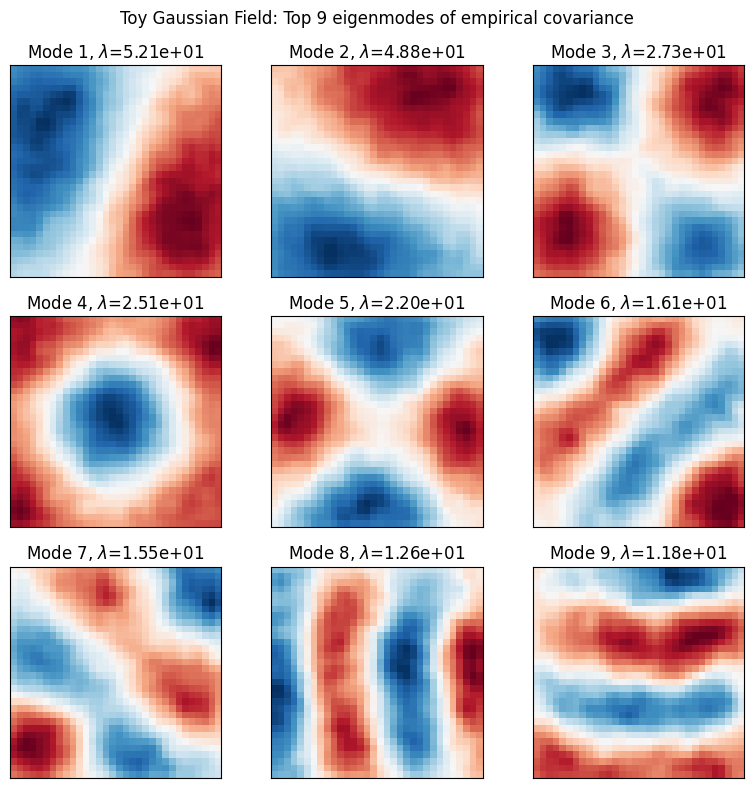

In [36]:
# Full empirical covariance of training samples (flattened), then diagonalize and plot top eigenmodes
# Samples: (N, 1, H, W) -> (N, H*W)
X = train_x0.reshape(train_x0.shape[0], -1).cpu().numpy()
X_centered = X - X.mean(axis=0)
n_samples, n_pixels = X_centered.shape
# Covariance (n_pixels x n_pixels)
cov = (X_centered.T @ X_centered) / max(n_samples - 1, 1)
# Diagonalize (symmetric)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
# Top singular value eigenmodes = top eigenvectors (same as left singular vectors of X_centered up to sign)
num_modes = 9
h, w = cfg.image_size, cfg.image_size
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i in range(num_modes):
    ax = axes.flat[i]
    mode = eigenvectors[:, i].reshape(h, w)
    im = ax.imshow(mode, cmap="RdBu_r", aspect="equal")
    ax.set_title(f"Mode {i+1}, $\\lambda$={eigenvalues[i]:.2e}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"{cfg.dataset_name}: Top 9 eigenmodes of empirical covariance")
plt.tight_layout()
plt.show()

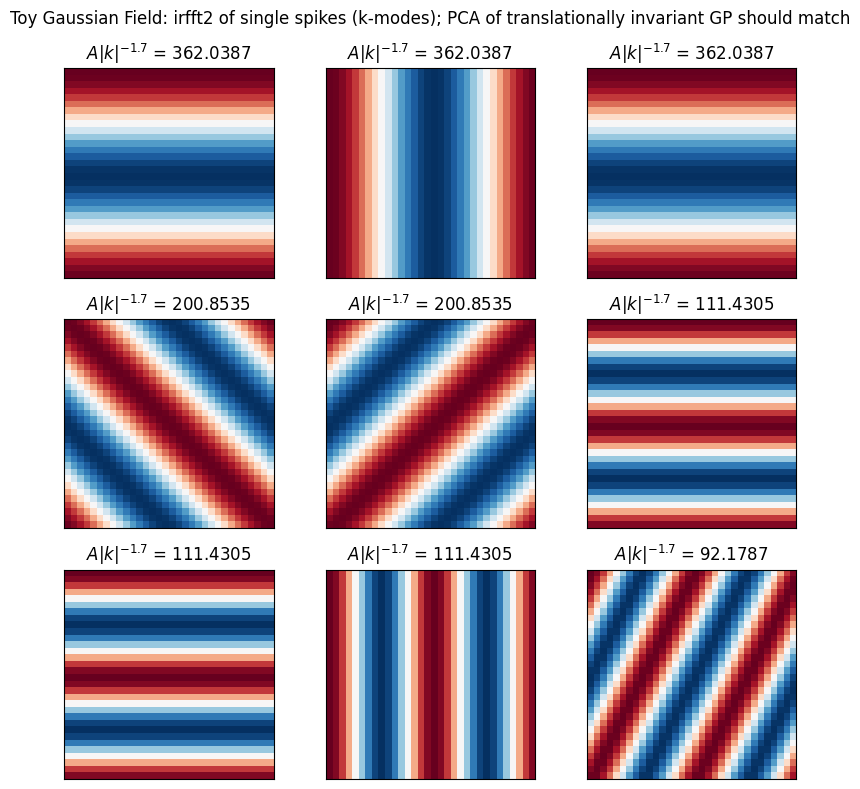

In [37]:
# irfft2 of single spikes: each panel is the real-space pattern of one k-mode.
# For a translationally invariant Gaussian process, PCA modes should match these k-modes.
H, W = cfg.image_size, cfg.image_size
ncol = W // 2 + 1
ky_1d = np.fft.fftfreq(H, d=1.0)
kx_1d = np.fft.rfftfreq(W, d=1.0)
kx_2d, ky_2d = np.meshgrid(kx_1d, ky_1d)
k_mag = np.sqrt(kx_2d**2 + ky_2d**2)
# Flatten and get (iy, ix) indices for modes with k > 0, sorted by k
flat_k = k_mag.ravel()
iy_flat = np.arange(H).reshape(-1, 1).repeat(ncol, axis=1).ravel()
ix_flat = np.arange(ncol).reshape(1, -1).repeat(H, axis=0).ravel()
valid = flat_k > 0
order = np.argsort(flat_k[valid])
# Pick top 9 k-modes (lowest |k|)
n_modes = 9
picks = np.where(valid)[0][order[:n_modes]]
iy_pick = iy_flat[picks]
ix_pick = ix_flat[picks]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i in range(n_modes):
    coeff = np.zeros((H, W // 2 + 1), dtype=complex)
    coeff[iy_pick[i], ix_pick[i]] = 1.0
    real_mode = np.fft.irfft2(coeff, s=(H, W), norm="ortho")
    ax = axes.flat[i]
    ax.imshow(real_mode, cmap="RdBu_r", aspect="equal")
    k_val = flat_k[picks[i]]
    cov_analytic = effective_amplitude * (k_val ** (-cfg.alpha))
    ax.set_title(rf"$A|k|^{{-{cfg.alpha:.1f}}}$ = {cov_analytic:.4f}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"{cfg.dataset_name}: irfft2 of single spikes (k-modes); PCA of translationally invariant GP should match")
plt.tight_layout()
plt.show()

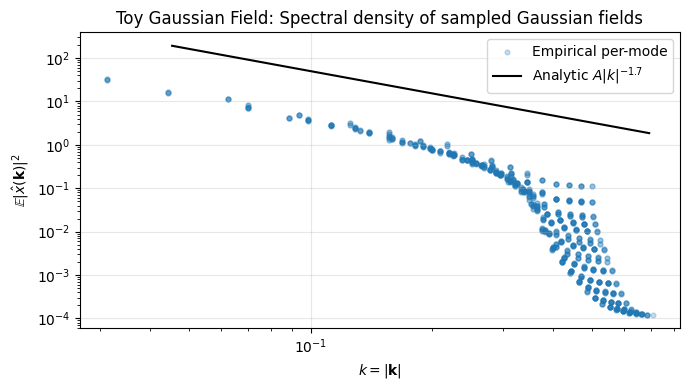

In [47]:
# Spectral density of sampled Gaussian fields
n_spectral = 256
samples_spectral = sample_powerlaw_gaussian_field(
    n_spectral,
    cfg.image_size,
    alpha=cfg.alpha,
    amplitude=effective_amplitude,
    seed=43,
    device=device,
)
x_np = samples_spectral[:, 0].cpu().numpy()  # [n, H, W]
fft_coeff = np.fft.fft2(x_np, axes=(-2, -1), norm="ortho")
emp_cov = np.mean(np.abs(fft_coeff) ** 2, axis=0)

freq = np.fft.fftfreq(cfg.image_size, d=1.0)
ky_full, kx_full = np.meshgrid(freq, freq, indexing="ij")
k_mag = np.sqrt(kx_full**2 + ky_full**2)
k_flat = k_mag.reshape(-1)
cov_flat = emp_cov.reshape(-1)
mask = k_flat > 0.0
k_flat = k_flat[mask]
cov_flat = cov_flat[mask]

nbins = 24
edges = np.linspace(k_flat.min(), k_flat.max(), nbins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
radial_cov = np.full(nbins, np.nan)
for i in range(nbins):
    bmask = (k_flat >= edges[i]) & (k_flat < edges[i + 1])
    if np.any(bmask):
        radial_cov[i] = np.mean(cov_flat[bmask])

valid = np.isfinite(radial_cov) & (radial_cov > 0) & (centers > 0)
analytic = effective_amplitude * np.power(centers, -cfg.alpha)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.scatter(k_flat, cov_flat, s=12, alpha=0.25, label="Empirical per-mode")
# ax.plot(centers[valid], radial_cov[valid], "o-", label="Radial mean")
ax.plot(centers[valid], analytic[valid], "k-", linewidth=1.5, label=rf"Analytic $A|k|^{{-{cfg.alpha:.1f}}}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$k=|\mathbf{k}|$")
ax.set_ylabel(r"$\mathbb{E}|\hat{x}(\mathbf{k})|^2$")
ax.set_title(f"{cfg.dataset_name}: Spectral density of sampled Gaussian fields")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_9957/4142497116.py:27: RuntimeWarning: divide by zero encountered in power
  ref = effective_amplitude*(k_ref) ** (-cfg.alpha)


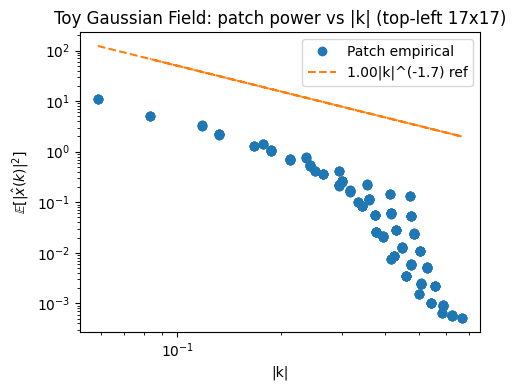

In [48]:
# Power spectrum of top-left kernel_size x kernel_size patch: E[|x̂(k)|^2] vs |k|
# Use all training samples' top-left patches
patches = train_x0[:, 0, :kernel_size, :kernel_size]  # [N, k, k]

# 2D FFT of each patch
patch_fft = torch.fft.fft2(patches, norm="ortho")
patch_power = patch_fft.abs() ** 2  # [N, k, k]

# Average over samples
mean_power_2d = patch_power.mean(dim=0)  # [k, k]



# Build |k| grid for this patch
ky = torch.fft.fftfreq(kernel_size, d=1.0)
kx = torch.fft.fftfreq(kernel_size, d=1.0)
ky2d, kx2d = torch.meshgrid(ky, kx, indexing="ij")
k_radius = torch.sqrt(kx2d**2 + ky2d**2)

k_flat = k_radius.flatten().cpu().numpy()
p_flat = mean_power_2d.flatten().detach().cpu().numpy()

# Reference power law ~ |k|^{-alpha}
if len(k_flat) > 0:
    k_ref = k_flat
    k0 = k_ref[0]
    ref = effective_amplitude*(k_ref) ** (-cfg.alpha)
else:
    ref = None
    k_ref = None

plt.figure(figsize=(5, 4))
plt.loglog(k_flat, p_flat, "o", label="Patch empirical")
if ref is not None:
    plt.loglog(k_ref, ref, "--", label=f"{effective_amplitude:.2f}|k|^(-{cfg.alpha}) ref")
plt.xlabel("|k|")
plt.ylabel(r"$\mathbb{E}[|\hat{x}(k)|^2]$")
plt.title(f"{cfg.dataset_name}: patch power vs |k| (top-left {kernel_size}x{kernel_size})")
plt.legend()
plt.tight_layout()
plt.show()

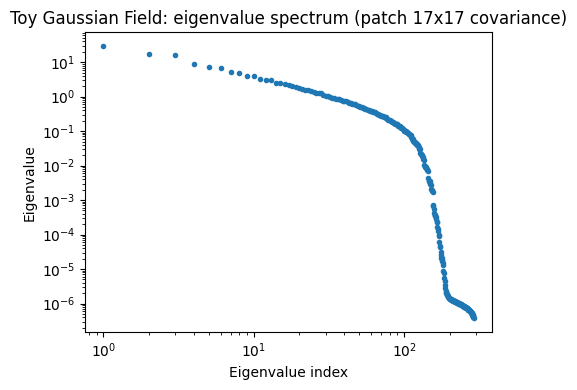

In [49]:
# Log-log plot: eigenvalue index vs eigenvalue (patch covariance)
patches = train_x0[:, 0, :kernel_size, :kernel_size].reshape(train_x0.shape[0], -1).cpu().numpy()
patches_centered = patches - patches.mean(axis=0)
cov_patch = (patches_centered.T @ patches_centered) / max(patches_centered.shape[0] - 1, 1)
evals_patch, _ = np.linalg.eigh(cov_patch)
evals_patch = np.sort(evals_patch)[::-1]

inds = np.arange(1, len(evals_patch) + 1, dtype=float)
plt.figure(figsize=(5, 4))
plt.loglog(inds, evals_patch, "o", markersize=3)
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.title(f"{cfg.dataset_name}: eigenvalue spectrum (patch {kernel_size}x{kernel_size} covariance)")
plt.tight_layout()
plt.show()

In [50]:
evals_patch, len(evals_patch)

(array([2.95137253e+01, 1.71896458e+01, 1.60548172e+01, 8.56657982e+00,
        7.19431257e+00, 6.94250345e+00, 5.10447407e+00, 4.83507395e+00,
        4.00327826e+00, 3.98465705e+00, 3.34015560e+00, 3.11840129e+00,
        2.99953485e+00, 2.52914739e+00, 2.43793964e+00, 2.29585052e+00,
        2.12931848e+00, 1.99203444e+00, 1.91890323e+00, 1.77089548e+00,
        1.61941028e+00, 1.57973289e+00, 1.56580806e+00, 1.43303084e+00,
        1.40331817e+00, 1.31234145e+00, 1.27626657e+00, 1.24792337e+00,
        1.14744782e+00, 1.06377280e+00, 1.03572977e+00, 9.84795570e-01,
        9.38284695e-01, 9.08920944e-01, 8.79962862e-01, 8.47578287e-01,
        8.26694548e-01, 7.97769189e-01, 7.64444709e-01, 7.48617530e-01,
        7.31061518e-01, 6.78860545e-01, 6.59238219e-01, 6.56135976e-01,
        6.24766946e-01, 6.13124251e-01, 5.92546642e-01, 5.71967244e-01,
        5.42923152e-01, 5.32258749e-01, 5.06613433e-01, 5.02285421e-01,
        4.82113421e-01, 4.68665957e-01, 4.49936986e-01, 4.433996

In [42]:
17*(17//2+1)

153

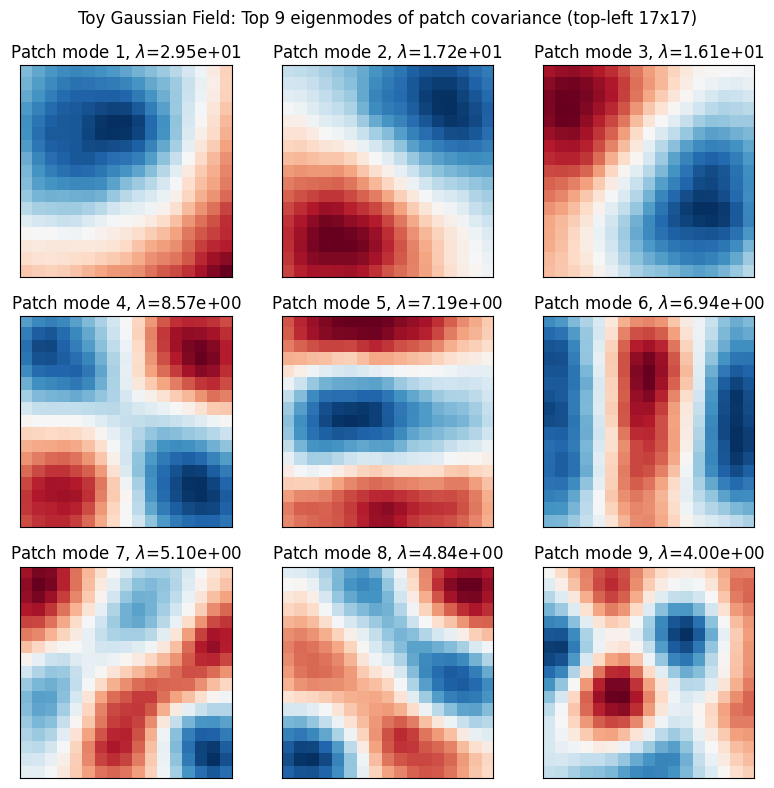

In [43]:
# Empirical covariance eigenmodes for top-left kernel_size x kernel_size patch
# Use all training samples' top-left patches, vectorized, and diagonalize covariance

# Extract and flatten patches: (N, 1, H, W) -> (N, k*k)
patches = train_x0[:, 0, :kernel_size, :kernel_size].reshape(train_x0.shape[0], -1).cpu().numpy()
patches_centered = patches - patches.mean(axis=0)

n_samples_patch, n_pixels_patch = patches_centered.shape
cov_patch = (patches_centered.T @ patches_centered) / max(n_samples_patch - 1, 1)

# Diagonalize symmetric covariance
evals_patch, evecs_patch = np.linalg.eigh(cov_patch)
idx_patch = np.argsort(evals_patch)[::-1]
evals_patch = evals_patch[idx_patch]
evecs_patch = evecs_patch[:, idx_patch]

num_modes_patch = 9
h_p = w_p = kernel_size
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i in range(num_modes_patch):
    ax = axes.flat[i]
    mode = evecs_patch[:, i].reshape(h_p, w_p)
    im = ax.imshow(mode, cmap="RdBu_r", aspect="equal")
    ax.set_title(f"Patch mode {i+1}, $\\lambda$={evals_patch[i]:.2e}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"{cfg.dataset_name}: Top 9 eigenmodes of patch covariance (top-left {kernel_size}x{kernel_size})")
plt.tight_layout()
plt.show()

In [44]:
def square_radial_density(R, s):
    """Square radial density: 2*pi*R for R < s, 4*(arcsin(s/R) - arccos(s/R)) for s < R < sqrt(2)*s, 0 for R > sqrt(2)*s."""
    R = np.asarray(R, dtype=np.float64)
    out = np.zeros_like(R)
    sqrt2_s = np.sqrt(2.0) * s
    mask_small = (R > 0) & (R < s)
    mask_mid = (R >= s) & (R < sqrt2_s)
    out[mask_small] = 2.0 * np.pi * R[mask_small]
    # arcsin(s/R) - arccos(s/R) = 2*arcsin(s/R) - pi/2 for s/R in (0, 1]
    out[mask_mid] = 4.0 * R[mask_mid] * (np.arcsin(np.clip(s / R[mask_mid], 1e-12, 1.0)) - np.arccos(np.clip(s / R[mask_mid], 1e-12, 1.0)))
    return out


def square_continuum_mutual_information(snr_value, amplitude, alpha, s, patch_pixels, num_k=4096):
    """Continuum MI in nats using square radial density: (1/2) int dmu(R) log(1 + SNR*A*R^{-alpha}).
    dmu(R) = (density(R) / norm) dR with int dmu = patch_pixels."""
    sqrt2_s = np.sqrt(2.0) * s
    R_min = s * 1e-6  # avoid R=0
    R_grid = np.linspace(R_min, sqrt2_s, num_k, dtype=np.float64)
    rho = square_radial_density(R_grid, s)
    norm = np.trapz(rho, R_grid)
    if norm <= 0:
        return 0.0
    # dmu = (rho / norm) * patch_pixels so that int dmu = patch_pixels
    integrand = (rho / norm) * patch_pixels * 0.5 * np.log(1.0 + snr_value * amplitude * np.power(R_grid, -alpha))
    return float(np.trapz(integrand, R_grid))

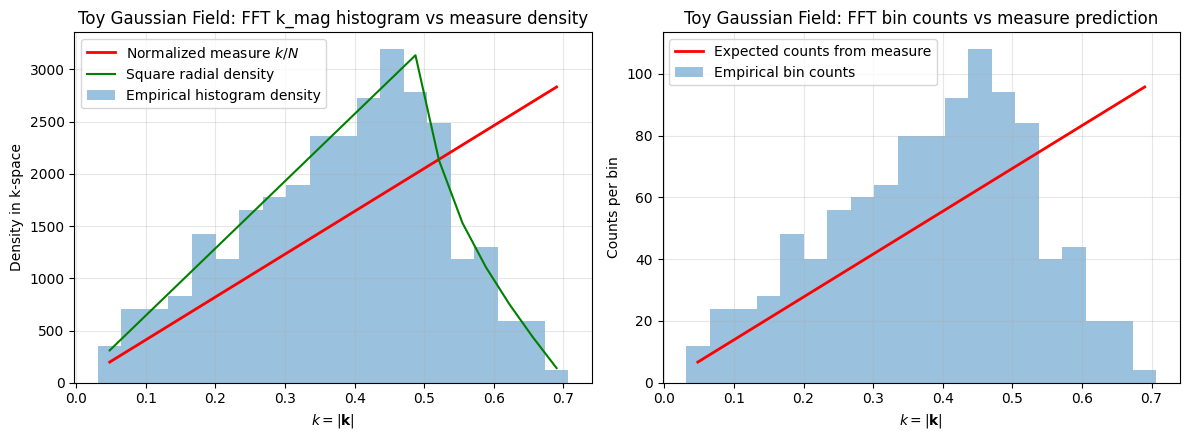

Total nonzero frequencies in histogram: 1022
Total expected nonzero count from measure over [IR, UV]: 1024.000
Patch pixels P: 1024


In [45]:
# Discrete FFT magnitudes from the same 2D frequency lattice
k_vals = k_mag.reshape(-1)
k_vals_nz = k_vals[k_vals > 0.0]

# Histogram on [lambda_ir, lambda_uv]
lambda_ir = 1/cfg.image_size
lambda_uv = 1/np.sqrt(2)
patch_pixels = cfg.image_size**2
nbins = 20
counts, edges = np.histogram(k_vals_nz, bins=nbins, range=(lambda_ir, lambda_uv))
centers = 0.5 * (edges[:-1] + edges[1:])
widths = np.diff(edges)

# Empirical density: counts per unit k
rho_emp = counts / widths

# Continuum normalized measure density rho_mu(k) = k / N with ∫ rho_mu dk = patch_pixels
integral_k = 0.5 * (lambda_uv**2 - lambda_ir**2)
N = integral_k / patch_pixels
rho_mu = centers / N

# Square radial density (same scale as histogram: s so support is (0, lambda_uv])
s_square = lambda_uv / np.sqrt(2)
rho_square_raw = square_radial_density(centers, s_square)
R_fine = np.linspace(1e-8, np.sqrt(2) * s_square, 500)
integral_square = np.trapz(square_radial_density(R_fine, s_square), R_fine)
rho_square_norm = rho_square_raw * (patch_pixels / integral_square)

# Optional: expected bin counts under continuum measure
expected_counts = 0.5 * ((edges[1:]**2 - edges[:-1]**2) / N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(centers, rho_emp, width=widths, alpha=0.45, label="Empirical histogram density")
axes[0].plot(centers, rho_mu, "r-", linewidth=2.0, label=r"Normalized measure $k/N$")
axes[0].plot(centers, rho_square_norm, "g-", linewidth=1.5, label="Square radial density")
axes[0].set_xlabel(r"$k=|\mathbf{k}|$")
axes[0].set_ylabel("Density in k-space")
axes[0].set_title(f"{cfg.dataset_name}: FFT k_mag histogram vs measure density")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(centers, counts, width=widths, alpha=0.45, label="Empirical bin counts")
axes[1].plot(centers, expected_counts, "r-", linewidth=2.0, label="Expected counts from measure")
axes[1].set_xlabel(r"$k=|\mathbf{k}|$")
axes[1].set_ylabel("Counts per bin")
axes[1].set_title(f"{cfg.dataset_name}: FFT bin counts vs measure prediction")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total nonzero frequencies in histogram: {int(np.sum(counts))}")
print(f"Total expected nonzero count from measure over [IR, UV]: {float(np.sum(expected_counts)):.3f}")
print(f"Patch pixels P: {patch_pixels}")

## Analytic Entropy Prediction vs LS and ELS

**Continuum mutual information** (in nats):
$$
I_{\mathrm{cont}}(\mathrm{SNR}) = \frac{1}{2}\int_{\Lambda_{IR}}^{\Lambda_{UV}} d\mu(k)\,\log\left(1+\mathrm{SNR}\cdot A\,|k|^{-\alpha}\right).
$$

**Discrete mutual information** (in nats):
$$
I_{\mathrm{disc}}(\mathrm{SNR}) = \frac{1}{2}\sum_{\mathbf{k}} \log\left(1+\mathrm{SNR}\cdot A\,|\mathbf{k}|^{-\alpha}\right).
$$

Entropy is then $S = \max\{0, \log|D| - I\}$ (nats), with $I$ either $I_{\mathrm{cont}}$ or $I_{\mathrm{disc}}$. The code below defines `continuum_mutual_information`, `discrete_mutual_information`, and entropy functions that use them.

Spectral measure normalization:
$$
d\mu(k)=\frac{k\,dk}{N}, \qquad \int_{\Lambda_{IR}}^{\Lambda_{UV}}\frac{k}{N}\,dk = P,
$$
where $P$ is the number of pixels in the patch. In this notebook we use full-image patches, so $P=H\times W = L^2$. 

Also, $\Lambda_{IR}=\frac{1}{L}$ where L in the image side length and $\Lambda_{UV} = \frac{1}{\sqrt{2}}$

In [55]:
if results["snr"]:
    beta_values = np.array(results["snr"])
else:
    beta_values = cosine_noise_schedule(torch.tensor(np.array(cfg.t_values))).cpu().numpy()

D_ls = int(cfg.n_train)
D_els = int(cfg.n_train * cfg.image_size * cfg.image_size)

def continuum_mutual_information(snr_value, amplitude, alpha, lambda_ir, lambda_uv, patch_pixels, num_k=4096):
    """Continuum MI in nats: (1/2) int dmu(k) log(1 + SNR*A*|k|^{-alpha}), dmu(k) = (k/N) dk, int dmu = patch_pixels."""
    k = np.linspace(lambda_ir, lambda_uv, num_k, dtype=np.float64)
    integral_k = 0.5 * (lambda_uv**2 - lambda_ir**2)
    N = integral_k / patch_pixels
    integrand = 0.5 * np.log(1.0 + snr_value * amplitude * np.power(k, -alpha))
    return float(np.trapz((k / N) * integrand, k))

patch_pixels = kernel_size**2
lambda_ir = 1/kernel_size
lambda_uv = 1/np.sqrt(2)

continum_circle_mi = [
    continuum_mutual_information(b, D_ls, effective_amplitude, cfg.alpha, lambda_ir, lambda_uv, patch_pixels)
    for b in beta_values
]
continum_circle_mi = np.array(continum_circle_mi)

In [58]:
def discrete_mutual_information(snr_value, amplitude, alpha, patch_side_length, include_zero_mode=False):
    """Discrete MI in nats: (1/2) sum_k log(1 + SNR*A*|k|^{-alpha})."""
    image_size = patch_side_length**2
    
    ky = torch.fft.fftfreq(patch_side_length, d=1.0, device=device)[:, None]
    kx = torch.fft.rfftfreq(patch_side_length, d=1.0, device=device)[None, :]
    k = torch.sqrt(kx**2 + ky**2)
    
#     print(k.shape)
    
    power = amplitude * torch.where(k > 0, k.pow(-alpha), torch.zeros_like(k))
#     print(len(power.flatten().cpu().numpy()))
#     print(np.sort(power.flatten().cpu().numpy()))
    # Interior: scale = sqrt(power/2). Only x-edges (kx=0, kx=N/2) need double variance; y-edges do not (rfft stores all ky but only kx>=0).
    scale = torch.sqrt(torch.clamp(power, min=0.0)/2.0)
    ix = torch.arange(patch_side_length // 2 + 1, device=device)
    col_edge = (ix == 0) | (ix == image_size // 2)
    
#     print(torch.sqrt(torch.clamp(scale, min=0.0)).shape)
#     print(scale.shape)
#     print(col_edge[None, :].shape)
    
    scale = torch.where(col_edge[None, :], torch.sqrt(torch.clamp(scale, min=0.0)), scale)
    iy = torch.arange(patch_side_length, device=device)
    row_edge = (iy == 0) | (iy == image_size // 2)
    corner_mode = row_edge[:, None] & col_edge[None, :]
    
#     print(np.sort(scale.flatten().cpu().numpy()))
    
    real_scale = scale
    imag_scale = torch.where(corner_mode, torch.zeros_like(scale), scale)
    
#     print(np.sum(real_scale.cpu().numpy() != 0.0) + np.sum(imag_scale.cpu().numpy() != 0.0))
#     print(image_size)

    terms = 0.5 * torch.log(1.0 + snr_value * torch.square(real_scale)) + 0.5 * torch.log(1.0 + snr_value * torch.square(imag_scale))
    
    return float(torch.sum(terms))

discrete_mutual_information(0.5, effective_amplitude, cfg.alpha, kernel_size)

discrete_mi = [
    discrete_mutual_information(b, effective_amplitude, cfg.alpha, kernel_size)
    for b in beta_values
]
discrete_mi = np.array(discrete_mi)

In [60]:
def gaussian_mutual_information(snr_value, covariance_singular_values):
    """Discrete MI in nats: (1/2) sum_k log(1 + SNR*A*|k|^{-alpha})."""
    
    return 0.5*np.sum(np.log(1.0 + snr_value*covariance_singular_values))

# Log-log plot: eigenvalue index vs eigenvalue (patch covariance)
patches = train_x0[:, 0, :kernel_size, :kernel_size].reshape(train_x0.shape[0], -1).cpu().numpy()
patches_centered = patches - patches.mean(axis=0)
cov_patch = (patches_centered.T @ patches_centered) / max(patches_centered.shape[0] - 1, 1)
evals_patch, _ = np.linalg.eigh(cov_patch)

gaussian_mi = [
    gaussian_mutual_information(b, evals_patch)
    for b in beta_values
]
gaussian_mi = np.array(gaussian_mi)

In [62]:
# beta_values = np.array(results["snr"], dtype=np.float64)  # beta = SNR
patch_pixels = int(cfg.image_size * cfg.image_size)

D_ls = int(cfg.n_train)
D_els = int(cfg.n_train * cfg.image_size * cfg.image_size)

continuum_approximation_ls = np.maximum(np.zeros_like(beta_values), np.log(D_ls) - continum_circle_mi)
continuum_approximation_els = np.maximum(np.zeros_like(beta_values), np.log(D_els) - continum_circle_mi)

discrete_ls = np.maximum(np.zeros_like(beta_values), np.log(D_ls) - discrete_mi)
discrete_els = np.maximum(np.zeros_like(beta_values), np.log(D_els) - discrete_mi)

gaussian_ls = np.maximum(np.zeros_like(beta_values), np.log(D_ls) - gaussian_mi)
gaussian_els = np.maximum(np.zeros_like(beta_values), np.log(D_els) - gaussian_mi)

print(f"lambda_ir={lambda_ir:.4f}, lambda_uv={lambda_uv:.4f}")
print("beta is set to SNR")
print(f"patch_pixels={patch_pixels}")
print(f"|D|_LS={D_ls}, |D|_ELS={D_els}")

lambda_ir=0.0588, lambda_uv=0.7071
beta is set to SNR
patch_pixels=1024
|D|_LS=2000, |D|_ELS=2048000


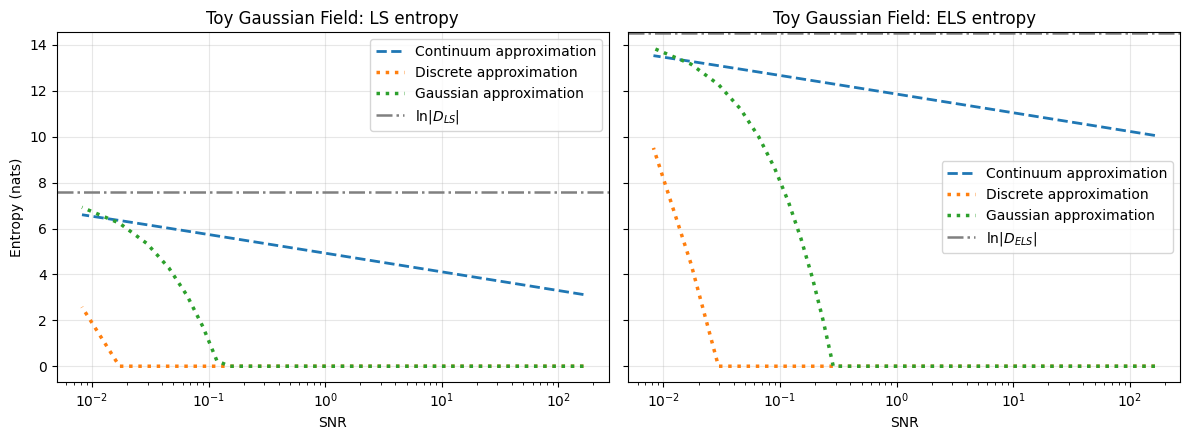

In [63]:
# Entropy S = max(0, ln|D| - I). The discrete MI I_disc is the same for LS and ELS; the curves
# differ because |D_LS| = train_posterior_samples and |D_ELS| = train_posterior_samples * H*W.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

logD_ls_nats = np.log(D_ls)
logD_els_nats = np.log(D_els)

# LS comparison
axes[0].plot(beta_values, continuum_approximation_ls, "--", linewidth=2.0, label="Continuum approximation")
axes[0].plot(beta_values, discrete_ls, ":", linewidth=2.5, label="Discrete approximation")
axes[0].plot(beta_values, gaussian_ls, ":", linewidth=2.5, label="Gaussian approximation")
axes[0].axhline(logD_ls_nats, color="gray", linestyle="-.", linewidth=1.8, label=r"$\ln|D_{LS}|$")
axes[0].set_xscale("log")
axes[0].set_xlabel("SNR")
axes[0].set_ylabel("Entropy (nats)")
axes[0].set_title(f"{cfg.dataset_name}: LS entropy")
axes[0].grid(alpha=0.3)
axes[0].legend()

# ELS comparison
axes[1].plot(beta_values, continuum_approximation_els, "--", linewidth=2.0, label="Continuum approximation")
axes[1].plot(beta_values, discrete_els, ":", linewidth=2.5, label="Discrete approximation")
axes[1].plot(beta_values, gaussian_els, ":", linewidth=2.5, label="Gaussian approximation")
axes[1].axhline(logD_els_nats, color="gray", linestyle="-.", linewidth=1.8, label=r"$\ln|D_{ELS}|$")
axes[1].set_xscale("log")
axes[1].set_xlabel("SNR")
axes[1].set_title(f"{cfg.dataset_name}: ELS entropy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save LS/ELS entropy comparison plot (previous cell) as SVG

save_dir = ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)

out_path = save_dir / f"ls_els_entropy_vs_snr_{cfg.dataset_name}.svg"
fig = plt.gcf()
fig.savefig(out_path, format="svg")
print(f"Saved {out_path}")

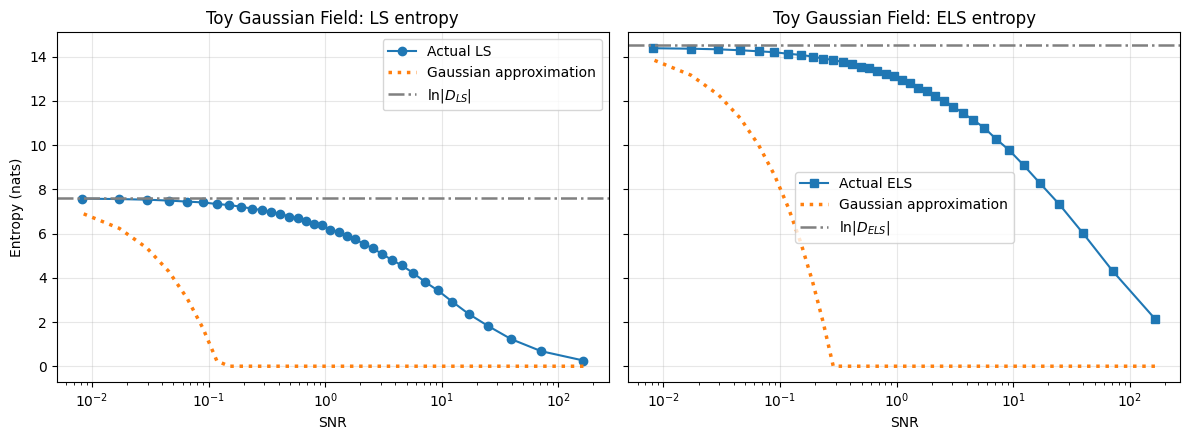

LS MAE (continuum_approximation) = 1.3540 nats | LS MAE (discrete) = 5.4215 nats
ELS MAE (continuum_approximation) = 1.6513 nats | ELS MAE (discrete) = 11.4823 nats


In [67]:
# Entropy S = max(0, ln|D| - I). The discrete MI I_disc is the same for LS and ELS; the curves
# differ because |D_LS| = train_posterior_samples and |D_ELS| = train_posterior_samples * H*W.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

logD_ls_nats = np.log(D_ls)
logD_els_nats = np.log(D_els)

# LS comparison
axes[0].plot(results["snr"], results["LS"], "o-", label="Actual LS")
# axes[0].plot(beta_values, continuum_approximation_ls, "--", linewidth=2.0, label="Continuum approximation")
# axes[0].plot(beta_values, discrete_ls, ":", linewidth=2.5, label="Discrete approximation")
axes[0].plot(beta_values, gaussian_ls, ":", linewidth=2.5, label="Gaussian approximation")
axes[0].axhline(logD_ls_nats, color="gray", linestyle="-.", linewidth=1.8, label=r"$\ln|D_{LS}|$")
axes[0].set_xscale("log")
axes[0].set_xlabel("SNR")
axes[0].set_ylabel("Entropy (nats)")
axes[0].set_title(f"{cfg.dataset_name}: LS entropy")
axes[0].grid(alpha=0.3)
axes[0].legend()

# ELS comparison
axes[1].plot(results["snr"], results["ELS"], "s-", label="Actual ELS")
# axes[1].plot(beta_values, continuum_approximation_els, "--", linewidth=2.0, label="Continuum approximation")
# axes[1].plot(beta_values, discrete_els, ":", linewidth=2.5, label="Discrete approximation")
axes[1].plot(beta_values, gaussian_els, ":", linewidth=2.5, label="Gaussian approximation")
axes[1].axhline(logD_els_nats, color="gray", linestyle="-.", linewidth=1.8, label=r"$\ln|D_{ELS}|$")
axes[1].set_xscale("log")
axes[1].set_xlabel("SNR")
axes[1].set_title(f"{cfg.dataset_name}: ELS entropy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

ls_mae_cont = float(np.mean(np.abs(np.array(results["LS"]) - np.array(continuum_approximation_ls))))
ls_mae_disc = float(np.mean(np.abs(np.array(results["LS"]) - np.array(discrete_ls))))
els_mae_cont = float(np.mean(np.abs(np.array(results["ELS"]) - np.array(continuum_approximation_els))))
els_mae_disc = float(np.mean(np.abs(np.array(results["ELS"]) - np.array(discrete_els))))

print(f"LS MAE (continuum_approximation) = {ls_mae_cont:.4f} nats | LS MAE (discrete) = {ls_mae_disc:.4f} nats")
print(f"ELS MAE (continuum_approximation) = {els_mae_cont:.4f} nats | ELS MAE (discrete) = {els_mae_disc:.4f} nats")

## Entropy deficit for LS vs SNR (varying training set size)

Plot **entropy deficit** \(\ln|D| - S\) (nats) for the LS posterior, where \(|D|\) is the number of training samples (posterior support). Each curve uses a different cap on \(|D|\): \(2^4, 2^5, \ldots, 2^{16}\) (capped by dataset size).

In [14]:
# Training set sizes: 2^4, 2^5, ..., 2^16 (capped by dataset size)
n_train_powers = list(range(8, 19))
max_available = len(train_dataset)
n_train_list = [min(2**k, max_available) for k in n_train_powers]
# Use unique sizes only (when 2^k > max_available we get duplicates)
n_train_list = sorted(set(n_train_list))

# Test entropies: deficits use noisy observations from eval_x0 (test set).
entropy_deficit_by_n = {}  # n_train -> list of deficit per t (same order as cfg.t_values)
snr_grid = np.array(results["snr"])

for n_train in n_train_list:
    with torch.no_grad():
        ls_n = build_candidate_bank(
            "ls",
            train_dataset,
            cfg.image_size,
            channels=eval_x0.shape[1],
            score_batch_size=cfg.score_batch_size,
            max_samples=n_train,
        )
        deficits = []
        for t_val in cfg.t_values:
            t = torch.tensor([t_val], device=device, dtype=torch.float32)
            beta_t = cosine_noise_schedule(t)
            at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
            bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))
            # Noisy test observation (eval_x0)
            eps = torch.randn_like(eval_x0, device=device)
            xt = at * eval_x0 + bt * eps
            s_nats = posterior_entropy_nats_from_score_machine(ls_n, t, xt)
            log_D = np.log(n_train)
            deficits.append(float(log_D - s_nats))
            if cfg.empty_cache_each_call and device.type == "cuda":
                torch.cuda.empty_cache()
        entropy_deficit_by_n[n_train] = np.array(deficits)
    del ls_n
    if device.type == "cuda":
        torch.cuda.empty_cache()

In [ ]:
# Global ideal LS entropy vs finite-sample LS entropy
snr_arr = np.array(results["snr"], dtype=np.float64)
ls_entropy = np.array(results["LS"], dtype=np.float64)
ideal_entropy = np.array(results["Ideal"], dtype=np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

# Left: entropies vs SNR
axes[0].plot(snr_arr, ideal_entropy, "k-", linewidth=2.0, label="Ideal LS (global)")
axes[0].plot(snr_arr, ls_entropy, "o-", label="Finite LS (samples)")
axes[0].set_xscale("log")
axes[0].set_xlabel("SNR")
axes[0].set_ylabel("Entropy (nats)")
axes[0].set_title(f"{cfg.dataset_name}: LS vs ideal LS entropy")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Right: difference ideal - LS
delta = ideal_entropy - ls_entropy
axes[1].plot(snr_arr, delta, "o-")
axes[1].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[1].set_xscale("log")
axes[1].set_xlabel("SNR")
axes[1].set_ylabel(r"Ideal $-$ LS entropy (nats)")
axes[1].set_title(f"{cfg.dataset_name}: ideal minus LS entropy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

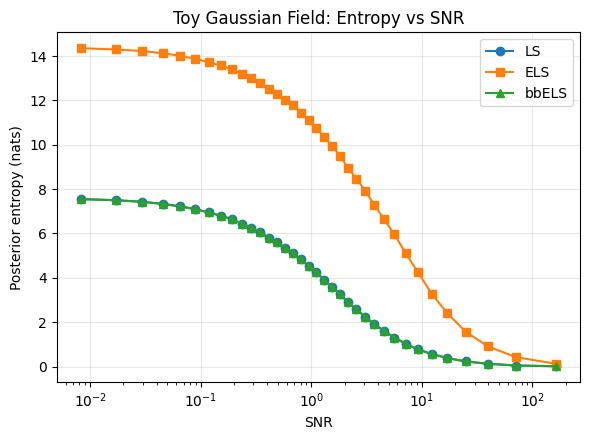

t=0.05 | SNR=1.641e+02 | H_LS=0.014, H_ELS=0.121, H_bbELS=0.014
t=0.08 | SNR=7.117e+01 | H_LS=0.045, H_ELS=0.420, H_bbELS=0.045
t=0.10 | SNR=3.936e+01 | H_LS=0.126, H_ELS=0.913, H_bbELS=0.126
t=0.13 | SNR=2.481e+01 | H_LS=0.230, H_ELS=1.572, H_bbELS=0.230
t=0.15 | SNR=1.696e+01 | H_LS=0.385, H_ELS=2.403, H_bbELS=0.385
t=0.18 | SNR=1.225e+01 | H_LS=0.566, H_ELS=3.284, H_bbELS=0.566
t=0.20 | SNR=9.208e+00 | H_LS=0.771, H_ELS=4.255, H_bbELS=0.771
t=0.23 | SNR=7.126e+00 | H_LS=1.028, H_ELS=5.110, H_bbELS=1.028
t=0.26 | SNR=5.642e+00 | H_LS=1.307, H_ELS=5.960, H_bbELS=1.307
t=0.28 | SNR=4.546e+00 | H_LS=1.604, H_ELS=6.643, H_bbELS=1.604
t=0.31 | SNR=3.714e+00 | H_LS=1.914, H_ELS=7.287, H_bbELS=1.914
t=0.33 | SNR=3.069e+00 | H_LS=2.241, H_ELS=7.924, H_bbELS=2.241
t=0.36 | SNR=2.558e+00 | H_LS=2.581, H_ELS=8.472, H_bbELS=2.581
t=0.38 | SNR=2.147e+00 | H_LS=2.891, H_ELS=8.952, H_bbELS=2.891
t=0.41 | SNR=1.812e+00 | H_LS=3.267, H_ELS=9.503, H_bbELS=3.267
t=0.44 | SNR=1.536e+00 | H_LS=3.586, H_E

In [15]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4.5))

axes.plot(results["snr"], results["LS"], "o-", label="LS")
axes.plot(results["snr"], results["ELS"], "s-", label="ELS")
axes.plot(results["snr"], results["bbELS"], "^-", label="bbELS")
axes.set_xscale("log")
axes.set_xlabel("SNR")
axes.set_ylabel("Posterior entropy (nats)")
axes.set_title(f"{cfg.dataset_name}: Entropy vs SNR")
axes.grid(alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()

for i in range(len(results["t"])):
    print(
        f"t={results['t'][i]:.2f} | SNR={results['snr'][i]:.3e} | "
        f"H_LS={results['LS'][i]:.3f}, H_ELS={results['ELS'][i]:.3f}, H_bbELS={results['bbELS'][i]:.3f}"
    )


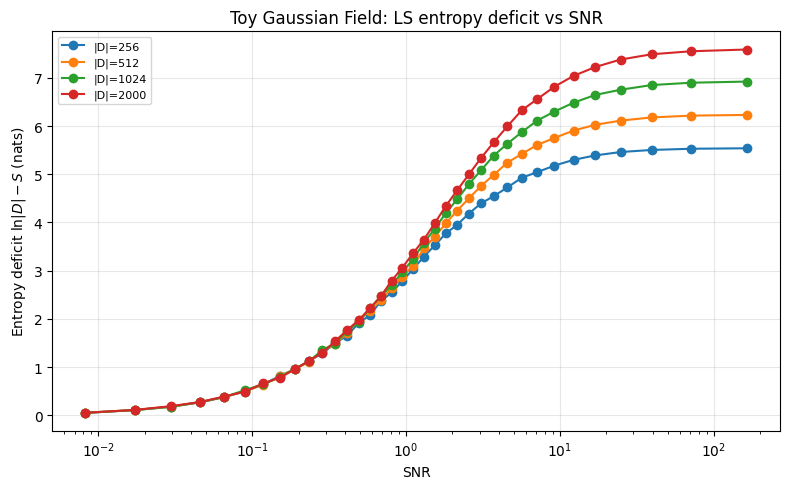

In [16]:
# Plot entropy deficit only (uses stored entropy_deficit_by_n, no recomputation)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for n_train in n_train_list:
    ax.plot(snr_grid, entropy_deficit_by_n[n_train], "o-", label=f"|D|={n_train}")
ax.set_xscale("log")
ax.set_xlabel("SNR")
ax.set_ylabel(r"Entropy deficit $\ln|D| - S$ (nats)")
ax.set_title(f"{cfg.dataset_name}: LS entropy deficit vs SNR")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## Histogram of FFT `k_mag` vs normalized measure

This compares the empirical distribution of discrete FFT magnitudes `k_mag` on the 2D grid to the continuum normalized measure density

\[
\rho_\mu(k)=\frac{k}{N}, \qquad \int_{\Lambda_{IR}}^{\Lambda_{UV}}\rho_\mu(k)\,dk=P,
\]

where \(P\) is the patch pixel count.

## Entropy deficit vs continuum and discrete MI

Same entropy deficit curves (no recomputation) with the analytic continuum and discrete mutual information approximations for comparison.

In [17]:
# Plot only (no recomputation): entropy deficit from stored entropy_deficit_by_n; MI from continuum_mutual_information and discrete_mutual_information
alpha=1.7
continuum_MI_nats = np.array([continuum_mutual_information(s, effective_amplitude, alpha, lambda_ir, lambda_uv, patch_pixels) for s in snr_grid])
discrete_MI_nats = np.array([discrete_mutual_information(s, effective_amplitude, alpha, k_mag, include_zero_mode=True) for s in snr_grid])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for n_train in n_train_list:
    ax.plot(snr_grid, entropy_deficit_by_n[n_train], "o-", label=f"Deficit |D|={n_train}")
ax.plot(snr_grid, continuum_MI_nats, "k--", linewidth=2, label="Continuum MI (approx)")
ax.plot(snr_grid, discrete_MI_nats, "k:", linewidth=2.5, label="Discrete MI (approx)")
ax.set_ylim(0, np.log(max(n_train_list)))
ax.set_xscale("log")
ax.set_xlabel("SNR")
ax.set_ylabel(r"Entropy deficit $\ln|D|-S$ (nats)  /  MI (nats)")
ax.set_title(f"{cfg.dataset_name}: LS entropy deficit and MI approximations vs SNR")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

TypeError: fft_fftfreq(): argument 'n' (position 1) must be int, not numpy.ndarray

## Discrete mutual information on FFT lattice

Define the discrete analytic quantity

$$I_{\mathrm{disc}}(\mathrm{SNR}) = \frac{1}{2}\sum_{\mathbf{k}\in\mathcal{K}_{\mathrm{FFT}},\,|\mathbf{k}|>0}
\log\left(1+\mathrm{SNR}\cdot A\,|\mathbf{k}|^{-\alpha}\right).$$

This is an explicit sum over the discrete FFT frequencies.

In [ ]:
def discrete_mutual_information(snr_value, amplitude, alpha, k_mag_grid, include_zero_mode=False):
    """Explicit discrete sum: 0.5 * sum_k log(1 + SNR * A * |k|^{-alpha})."""
    k_flat = np.asarray(k_mag_grid, dtype=np.float64).reshape(-1)
    if include_zero_mode:
        # Avoid singular k^{-alpha} at k=0; keep formula well-defined numerically.
        k_flat = np.maximum(k_flat, 1e-12)
    else:
        k_flat = k_flat[k_flat > 0.0]

    terms = 0.5 * np.log(1.0 + snr_value * amplitude * np.power(k_flat, -alpha))
    return float(np.sum(terms))


# Evaluate across the same SNR grid used above
discrete_mi = [
    discrete_mutual_information(s, effective_amplitude, cfg.alpha, k_mag, include_zero_mode=False)
    for s in results["snr"]
]

# Optional entropy-style prediction from the discrete MI
# S_approx_disc = max(0, log|D| - I_disc)
analytic_ls_discrete = [max(0.0, np.log(D_ls) - mi) / np.log(2.0) for mi in discrete_mi]
analytic_els_discrete = [max(0.0, np.log(D_els) - mi) / np.log(2.0) for mi in discrete_mi]

print("Computed discrete_mutual_information on SNR grid.")
print("Example:", {"snr": results["snr"][0], "I_disc": discrete_mi[0]})

## Continuum vs discrete mutual information (re-added)

This compares the continuum MI approximation

\[
I_{\mathrm{cont}}(\mathrm{SNR})=\frac{1}{2}\int_{\Lambda_{IR}}^{\Lambda_{UV}}\frac{k}{N}\log\left(1+\mathrm{SNR}\,A\,k^{-\alpha}\right)dk
\]

with the explicit discrete FFT-lattice sum

\[
I_{\mathrm{disc}}(\mathrm{SNR})=\frac{1}{2}\sum_{|\mathbf{k}|>0}\log\left(1+\mathrm{SNR}\,A\,|\mathbf{k}|^{-\alpha}\right).
\]

In [94]:
def continuum_mutual_information(snr_value, amplitude, alpha, lambda_ir, lambda_uv, patch_pixels, num_k=4096):
    """Continuum MI in nats using the same normalized measure as the entropy approximation."""
    k = np.linspace(lambda_ir, lambda_uv, num_k, dtype=np.float64)
    integral_k = 0.5 * (lambda_uv**2 - lambda_ir**2)
    N = integral_k / patch_pixels
    integrand = 0.5 * np.log(1.0 + snr_value * amplitude * np.power(k, -alpha))
    return float(np.trapz((k / N) * integrand, k))

def continuum_mutual_information_no_cutoff(snr_value, amplitude, alpha, patch_pixels, num_k=4096):
    return 0

def discrete_mutual_information_plot_ready(snr_value, amplitude, alpha, k_mag_grid):
    """Explicit discrete FFT sum for MI in nats, excluding zero mode."""
    k_flat = np.asarray(k_mag_grid, dtype=np.float64).reshape(-1)
    k_flat = k_flat[k_flat > 0.0]
    return float(np.sum(0.5 * np.log(1.0 + snr_value * amplitude * np.power(k_flat, -alpha))))


snr_grid = np.array(results["snr"], dtype=np.float64)
continuum_mi = [
    continuum_mutual_information(s, effective_amplitude, cfg.alpha, lambda_ir, lambda_uv, patch_pixels)
    for s in snr_grid
]
discrete_mi_plot = [
    discrete_mutual_information_plot_ready(s, effective_amplitude, cfg.alpha, k_mag)
    for s in snr_grid
]

plt.figure(figsize=(6.5, 4.5))
plt.plot(snr_grid, continuum_mi, "o--", label="Continuum MI")
plt.plot(snr_grid, discrete_mi_plot, "s-", label="Discrete MI")
plt.xscale("log")
plt.xlabel("SNR")
plt.ylabel("Mutual information (nats)")
plt.title(f"{cfg.dataset_name}: Continuum vs discrete MI")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Mean absolute MI gap (nats):", float(np.mean(np.abs(np.array(continuum_mi) - np.array(discrete_mi_plot)))))

NameError: name 'patch_pixels' is not defined